In [1]:
import sys

print(sys.executable)
print(sys.version)

d:\DeepFake\.venv\Scripts\python.exe
3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch version: 2.14.1+cpu
Device: CPU


In [3]:
import librosa
import soundfile as sf
import numpy as np
import pandas as pd
import sklearn

print("librosa:", librosa.__version__)
print("soundfile:", sf.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

librosa: 1.0.0
soundfile: 0.14.0
numpy: 2.5.3
pandas: 3.0.6


DWNLD DATASET

In [5]:
import kagglehub

path = kagglehub.dataset_download(
    "mohammedabdeldayem/avsspoof-2021"
)

print("Path to dataset files:", path)

d:\DeepFake\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 38.0M/58.0G [07:53<205:17:16, 84.2kB/s]


KeyboardInterrupt: 

In [6]:
import requests

url = "https://www.kaggle.com/api/v1/datasets/view/mohammedabdeldayem/avsspoof-2021"

response = requests.get(url)

print(response.status_code)

data = response.json()

print(data.keys())

200
dict_keys(['subtitleNullable', 'creatorNameNullable', 'totalBytesNullable', 'licenseNameNullable', 'descriptionNullable', 'ownerNameNullable', 'ownerRefNullable', 'titleNullable', 'currentVersionNumberNullable', 'usabilityRatingNullable', 'thumbnailImageUrlNullable', 'id', 'ref', 'subtitle', 'hasSubtitle', 'creatorName', 'hasCreatorName', 'creatorUrl', 'hasCreatorUrl', 'totalBytes', 'hasTotalBytes', 'url', 'hasUrl', 'lastUpdated', 'downloadCount', 'isPrivate', 'isFeatured', 'licenseName', 'hasLicenseName', 'description', 'hasDescription', 'ownerName', 'hasOwnerName', 'ownerRef', 'hasOwnerRef', 'kernelCount', 'title', 'hasTitle', 'topicCount', 'viewCount', 'voteCount', 'currentVersionNumber', 'hasCurrentVersionNumber', 'usabilityRating', 'hasUsabilityRating', 'tags', 'files', 'versions', 'thumbnailImageUrl', 'hasThumbnailImageUrl'])


In [7]:
for f in data.get("resources", []):
    print(f)

In [8]:
import requests

url = "https://www.kaggle.com/api/v1/datasets/view/mohammedabdeldayem/avsspoof-2021"

response = requests.get(url)

print("Status:", response.status_code)

data = response.json()

print(data.keys())

Status: 200
dict_keys(['subtitleNullable', 'creatorNameNullable', 'totalBytesNullable', 'licenseNameNullable', 'descriptionNullable', 'ownerNameNullable', 'ownerRefNullable', 'titleNullable', 'currentVersionNumberNullable', 'usabilityRatingNullable', 'thumbnailImageUrlNullable', 'id', 'ref', 'subtitle', 'hasSubtitle', 'creatorName', 'hasCreatorName', 'creatorUrl', 'hasCreatorUrl', 'totalBytes', 'hasTotalBytes', 'url', 'hasUrl', 'lastUpdated', 'downloadCount', 'isPrivate', 'isFeatured', 'licenseName', 'hasLicenseName', 'description', 'hasDescription', 'ownerName', 'hasOwnerName', 'ownerRef', 'hasOwnerRef', 'kernelCount', 'title', 'hasTitle', 'topicCount', 'viewCount', 'voteCount', 'currentVersionNumber', 'hasCurrentVersionNumber', 'usabilityRating', 'hasUsabilityRating', 'tags', 'files', 'versions', 'thumbnailImageUrl', 'hasThumbnailImageUrl'])


In [9]:
print(data)

{'subtitleNullable': 'Towards Spoofed and Deepfake Speech Detection in the Wild', 'creatorNameNullable': 'Mohammed Abdeldayem', 'totalBytesNullable': 62496218465, 'licenseNameNullable': 'Apache 2.0', 'descriptionNullable': 'The dataset paper link: https://arxiv.org/pdf/2210.02437.pdf\n\nBenchmarking initiatives support the meaningful comparison of competing solutions to prominent problems in speech and language processing. Successive benchmarking evaluations typically reflect a progressive evolution from ideal lab conditions towards to those encountered in the wild. ASVspoof, the spoofing and deepfake detection initiative and challenge series, has followed the same trend. This article provides a summary of the ASVspoof 2021 challenge and the results of 54 participating teams that submitted to the evaluation phase. For the logical access (LA) task, results indicate that countermeasures are robust to newly introduced encoding and transmission effects. Results for the physical access (PA)

In [10]:
for key, value in data.items():
    print("\nKEY:", key)
    print("TYPE:", type(value))

    if isinstance(value, list):
        print("LENGTH:", len(value))
        print("FIRST ITEM:", value[:2])
    elif isinstance(value, dict):
        print("SUBKEYS:", value.keys())


KEY: subtitleNullable
TYPE: <class 'str'>

KEY: creatorNameNullable
TYPE: <class 'str'>

KEY: totalBytesNullable
TYPE: <class 'int'>

KEY: licenseNameNullable
TYPE: <class 'str'>

KEY: descriptionNullable
TYPE: <class 'str'>

KEY: ownerNameNullable
TYPE: <class 'str'>

KEY: ownerRefNullable
TYPE: <class 'str'>

KEY: titleNullable
TYPE: <class 'str'>

KEY: currentVersionNumberNullable
TYPE: <class 'int'>

KEY: usabilityRatingNullable
TYPE: <class 'float'>

KEY: thumbnailImageUrlNullable
TYPE: <class 'str'>

KEY: id
TYPE: <class 'int'>

KEY: ref
TYPE: <class 'str'>

KEY: subtitle
TYPE: <class 'str'>

KEY: hasSubtitle
TYPE: <class 'bool'>

KEY: creatorName
TYPE: <class 'str'>

KEY: hasCreatorName
TYPE: <class 'bool'>

KEY: creatorUrl
TYPE: <class 'str'>

KEY: hasCreatorUrl
TYPE: <class 'bool'>

KEY: totalBytes
TYPE: <class 'int'>

KEY: hasTotalBytes
TYPE: <class 'bool'>

KEY: url
TYPE: <class 'str'>

KEY: hasUrl
TYPE: <class 'bool'>

KEY: lastUpdated
TYPE: <class 'str'>

KEY: downloadCou

In [11]:
# Show only the useful top-level metadata

print("Dataset title:", data.get("titleNullable"))
print("Description:", data.get("descriptionNullable"))
print("Total bytes:", data.get("totalBytesNullable"))

Dataset title: ASVspoof 2021 Dataset
Description: The dataset paper link: https://arxiv.org/pdf/2210.02437.pdf

Benchmarking initiatives support the meaningful comparison of competing solutions to prominent problems in speech and language processing. Successive benchmarking evaluations typically reflect a progressive evolution from ideal lab conditions towards to those encountered in the wild. ASVspoof, the spoofing and deepfake detection initiative and challenge series, has followed the same trend. This article provides a summary of the ASVspoof 2021 challenge and the results of 54 participating teams that submitted to the evaluation phase. For the logical access (LA) task, results indicate that countermeasures are robust to newly introduced encoding and transmission effects. Results for the physical access (PA) task indicate the potential to detect replay attacks in real, as opposed to simulated physical spaces, but a lack of robustness to variations between simulated and real acoust

In [12]:
print(data.keys())

dict_keys(['subtitleNullable', 'creatorNameNullable', 'totalBytesNullable', 'licenseNameNullable', 'descriptionNullable', 'ownerNameNullable', 'ownerRefNullable', 'titleNullable', 'currentVersionNumberNullable', 'usabilityRatingNullable', 'thumbnailImageUrlNullable', 'id', 'ref', 'subtitle', 'hasSubtitle', 'creatorName', 'hasCreatorName', 'creatorUrl', 'hasCreatorUrl', 'totalBytes', 'hasTotalBytes', 'url', 'hasUrl', 'lastUpdated', 'downloadCount', 'isPrivate', 'isFeatured', 'licenseName', 'hasLicenseName', 'description', 'hasDescription', 'ownerName', 'hasOwnerName', 'ownerRef', 'hasOwnerRef', 'kernelCount', 'title', 'hasTitle', 'topicCount', 'viewCount', 'voteCount', 'currentVersionNumber', 'hasCurrentVersionNumber', 'usabilityRating', 'hasUsabilityRating', 'tags', 'files', 'versions', 'thumbnailImageUrl', 'hasThumbnailImageUrl'])


In [13]:
import kagglehub
import inspect

print(inspect.signature(kagglehub.dataset_download))

(handle: str, path: str | None = None, *, force_download: bool | None = False, output_dir: str | None = None) -> str


In [14]:
import inspect
import kagglehub

print(inspect.getsource(kagglehub.dataset_download))

def dataset_download(
    handle: str,
    path: str | None = None,
    *,
    force_download: bool | None = False,
    output_dir: str | None = None,
) -> str:
    """Download dataset files
    Args:
        handle: (string) the dataset handle
        path: (string) Optional path to a file within a dataset
        force_download: (bool) Optional flag to force download a dataset, even if it's cached or already in output_dir.
        output_dir: (string) Optional output directory for direct download, bypassing the default cache.
    Returns:
        A string requesting the path to the requested dataset files.
    """
    h = parse_dataset_handle(handle)
    logger.info(f"Downloading Dataset: {h.to_url()} ...", extra={**EXTRA_CONSOLE_BLOCK})
    resolved_path, _ = registry.dataset_resolver(
        h,
        path,
        force_download=force_download,
        output_dir=output_dir,
    )
    return resolved_path



In [16]:
import kagglehub
import inspect

resolver = kagglehub.registry.dataset_resolver

print("Type:", type(resolver))
print("File:", inspect.getfile(resolver))
print("Methods/attributes:")
print(dir(resolver))

Type: <class 'kagglehub.registry.MultiImplRegistry'>


TypeError: module, class, method, function, traceback, frame, or code object was expected, got MultiImplRegistry

In [19]:
for key in data.keys():
    print(key)

subtitleNullable
creatorNameNullable
totalBytesNullable
licenseNameNullable
descriptionNullable
ownerNameNullable
ownerRefNullable
titleNullable
currentVersionNumberNullable
usabilityRatingNullable
thumbnailImageUrlNullable
id
ref
subtitle
hasSubtitle
creatorName
hasCreatorName
creatorUrl
hasCreatorUrl
totalBytes
hasTotalBytes
url
hasUrl
lastUpdated
downloadCount
isPrivate
isFeatured
licenseName
hasLicenseName
description
hasDescription
ownerName
hasOwnerName
ownerRef
hasOwnerRef
kernelCount
title
hasTitle
topicCount
viewCount
voteCount
currentVersionNumber
hasCurrentVersionNumber
usabilityRating
hasUsabilityRating
tags
files
versions
thumbnailImageUrl
hasThumbnailImageUrl


In [20]:
print(type(data["files"]))
print("Number of files:", len(data["files"]))

for i, f in enumerate(data["files"]):
    print("\nFILE", i)
    print(f)
    if i >= 4:
        break

<class 'list'>
Number of files: 0


In [21]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "mohammedabdeldayem",
    "dataset_slug": "avsspoof-2021",
    "path": ""
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:5000])

Status: 200
{"directories":[{"name":"ASVspoof2021_DF_eval_part00","relativeUrl":"ASVspoof2021_DF_eval_part00","totalDirectories":1,"totalChildren":1},{"name":"ASVspoof2021_DF_eval_part01","relativeUrl":"ASVspoof2021_DF_eval_part01","totalDirectories":1,"totalChildren":1},{"name":"ASVspoof2021_DF_eval_part02","relativeUrl":"ASVspoof2021_DF_eval_part02","totalDirectories":1,"totalChildren":1},{"name":"ASVspoof2021_LA_eval","relativeUrl":"ASVspoof2021_LA_eval","totalDirectories":1,"totalChildren":1},{"name":"ASVspoof2021_PA_eval_part00","relativeUrl":"ASVspoof2021_PA_eval_part00","totalDirectories":1,"totalChildren":1},{"name":"ASVspoof2021_PA_eval_part01","relativeUrl":"ASVspoof2021_PA_eval_part01","totalDirectories":1,"totalChildren":1},{"name":"ASVspoof2021_PA_eval_part02","relativeUrl":"ASVspoof2021_PA_eval_part02","totalDirectories":1,"totalChildren":1},{"name":"ASVspoof2021_PA_eval_part03","relativeUrl":"ASVspoof2021_PA_eval_part03","totalDirectories":1,"totalChildren":1},{"name":"D

In [22]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "mohammedabdeldayem",
    "dataset_slug": "avsspoof-2021",
    "path": "ASVspoof2021_DF_eval_part00"
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:5000])

Status: 200
{"directories":[{"name":"ASVspoof2021_DF_eval","relativeUrl":"ASVspoof2021_DF_eval_part00/ASVspoof2021_DF_eval","totalDirectories":1,"totalFiles":3,"totalChildren":1}],"totalChildren":1,"totalDirectories":1}


In [23]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "mohammedabdeldayem",
    "dataset_slug": "avsspoof-2021",
    "path": "ASVspoof2021_DF_eval_part00/ASVspoof2021_DF_eval"
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:10000])

Status: 200
{"directories":[{"name":"flac","relativeUrl":"ASVspoof2021_DF_eval_part00/ASVspoof2021_DF_eval/flac","totalFiles":152955}],"files":[{"name":"ASVspoof2021.DF.cm.eval.trl.txt","creationDate":"2024-05-18T17:40:31.858780700Z","totalBytes":7953777,"relativeUrl":"ASVspoof2021_DF_eval_part00/ASVspoof2021_DF_eval/ASVspoof2021.DF.cm.eval.trl.txt","description":""},{"name":"LICENSE.DF.txt","creationDate":"2024-05-18T17:40:31.858780700Z","totalBytes":2374,"relativeUrl":"ASVspoof2021_DF_eval_part00/ASVspoof2021_DF_eval/LICENSE.DF.txt"},{"name":"README.DF.txt","creationDate":"2024-05-18T17:40:31.858780700Z","totalBytes":2227,"relativeUrl":"ASVspoof2021_DF_eval_part00/ASVspoof2021_DF_eval/README.DF.txt"}],"totalChildren":4,"totalDirectories":1,"totalFiles":3}


In [24]:
import kagglehub

protocol_path = kagglehub.dataset_download(
    "mohammedabdeldayem/avsspoof-2021",
    path="ASVspoof2021_DF_eval_part00/ASVspoof2021_DF_eval/ASVspoof2021.DF.cm.eval.trl.txt",
    output_dir="D:/DeepFake/data"
)

print("Downloaded to:", protocol_path)

100%|██████████| 1.43M/1.43M [00:13<00:00, 112kB/s]

Extracting zip of ASVspoof2021.DF.cm.eval.trl.txt...
Downloaded to: D:/DeepFake/data\ASVspoof2021_DF_eval_part00/ASVspoof2021_DF_eval/ASVspoof2021.DF.cm.eval.trl.txt


In [25]:
from pathlib import Path

protocol_file = Path(protocol_path)

print("File exists:", protocol_file.exists())
print("Size:", protocol_file.stat().st_size / (1024 * 1024), "MB")

with open(protocol_file, "r") as f:
    for i in range(10):
        print(f.readline().strip())

File exists: True
Size: 7.585312843322754 MB
DF_E_2000011
DF_E_2000013
DF_E_2000024
DF_E_2000026
DF_E_2000027
DF_E_2000028
DF_E_2000031
DF_E_2000032
DF_E_2000040
DF_E_2000042


In [26]:
with open(protocol_file, "r") as f:
    for i in range(5):
        line = f.readline().strip()
        print(repr(line))

'DF_E_2000011'
'DF_E_2000013'
'DF_E_2000024'
'DF_E_2000026'
'DF_E_2000027'


In [27]:
with open(protocol_file, "r") as f:
    for i in range(5):
        line = f.readline().strip()
        parts = line.split()
        print("Columns:", len(parts))
        print(parts)

Columns: 1
['DF_E_2000011']
Columns: 1
['DF_E_2000013']
Columns: 1
['DF_E_2000024']
Columns: 1
['DF_E_2000026']
Columns: 1
['DF_E_2000027']


In [28]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "mohammedabdeldayem",
    "dataset_slug": "avsspoof-2021",
    "path": "DF-keys-full"
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:10000])

Status: 200
{"directories":[{"name":"keys","relativeUrl":"DF-keys-full/keys","totalDirectories":1,"totalChildren":1}],"totalChildren":1,"totalDirectories":1}


In [29]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "mohammedabdeldayem",
    "dataset_slug": "avsspoof-2021",
    "path": "DF-keys-full/keys"
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:10000])

Status: 200
{"directories":[{"name":"DF","relativeUrl":"DF-keys-full/keys/DF","totalDirectories":1,"totalFiles":1,"totalChildren":1}],"totalChildren":1,"totalDirectories":1}


In [30]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "mohammedabdeldayem",
    "dataset_slug": "avsspoof-2021",
    "path": "DF-keys-full/keys/DF"
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:10000])

Status: 200
{"directories":[{"name":"CM","relativeUrl":"DF-keys-full/keys/DF/CM","totalDirectories":4,"totalFiles":1,"totalChildren":4}],"files":[{"name":"README.txt","creationDate":"2024-05-18T17:40:31.858780700Z","totalBytes":719,"relativeUrl":"DF-keys-full/keys/DF/README.txt"}],"totalChildren":2,"totalDirectories":1,"totalFiles":1}


In [31]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "mohammedabdeldayem",
    "dataset_slug": "avsspoof-2021",
    "path": "DF-keys-full/keys/DF/CM"
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:10000])

Status: 200
{"directories":[{"name":"CQCC-GMM","relativeUrl":"DF-keys-full/keys/DF/CM/CQCC-GMM","totalFiles":1},{"name":"LFCC-GMM","relativeUrl":"DF-keys-full/keys/DF/CM/LFCC-GMM","totalFiles":1},{"name":"LFCC-LCNN","relativeUrl":"DF-keys-full/keys/DF/CM/LFCC-LCNN","totalFiles":1},{"name":"RawNet2","relativeUrl":"DF-keys-full/keys/DF/CM/RawNet2","totalFiles":1}],"files":[{"name":"trial_metadata.txt","creationDate":"2024-05-18T17:40:31.858780700Z","totalBytes":62086042,"relativeUrl":"DF-keys-full/keys/DF/CM/trial_metadata.txt","description":""}],"totalChildren":5,"totalDirectories":4,"totalFiles":1}


In [32]:
import kagglehub

readme_path = kagglehub.dataset_download(
    "mohammedabdeldayem/avsspoof-2021",
    path="DF-keys-full/keys/DF/README.txt",
    output_dir="D:/DeepFake/data"
)

print("Downloaded to:", readme_path)

with open(readme_path, "r") as f:
    print(f.read())

100%|██████████| 719/719 [00:00<00:00, 367kB/s]

Downloaded to: D:/DeepFake/data\DF-keys-full/keys/DF/README.txt

ASVspoof2021 key and meta label

This folder contains keys & meta data for ASVspoof2021 evaluation data.

./
|- CM                        
|   |- trial_metadata.txt    CM protocol with keys and meta labels
|   |- LFCC-GMM              
|   |   |- score.txt         Baseline LFCC-GMM CM score
|   |- ...
|
|- ASV                       (optional)
|   |- trial_metadata.txt    ASV protocl with keys and meta labels
|   |- ASVtorch_kaldi        
|       |- score.txt         Baseline ASV score
|
|- *-C012-*.npy              (optional) Pre-computed C012 cofficients

__author__ = "ASVspoof consortium"
__copyright__ = "Copyright 2022, ASVspoof consortium"



In [33]:
import kagglehub

metadata_path = kagglehub.dataset_download(
    "mohammedabdeldayem/avsspoof-2021",
    path="DF-keys-full/keys/DF/CM/trial_metadata.txt",
    output_dir="D:/DeepFake/data"
)

print("Downloaded to:", metadata_path)

100%|██████████| 6.50M/6.50M [01:01<00:00, 110kB/s]

Extracting zip of trial_metadata.txt...


Downloaded to: D:/DeepFake/data\DF-keys-full/keys/DF/CM/trial_metadata.txt


In [34]:
with open(metadata_path, "r") as f:
    for i in range(10):
        print(f.readline().strip())

LA_0023 DF_E_2000011 nocodec asvspoof A14 spoof notrim progress traditional_vocoder - - - -
TEF2 DF_E_2000013 low_m4a vcc2020 Task1-team20 spoof notrim eval neural_vocoder_nonautoregressive Task1 team20 FF E
TGF1 DF_E_2000024 mp3m4a vcc2020 Task2-team12 spoof notrim eval traditional_vocoder Task2 team12 FF G
LA_0043 DF_E_2000026 mp3m4a asvspoof A09 spoof notrim eval traditional_vocoder - - - -
LA_0021 DF_E_2000027 mp3m4a asvspoof A12 spoof notrim eval neural_vocoder_autoregressive - - - -
VCC2TM2 DF_E_2000028 low_mp3 vcc2018 SPO-N12 spoof notrim eval traditional_vocoder SPO N12 FM -
LA_0025 DF_E_2000031 high_m4a asvspoof A10 spoof notrim eval neural_vocoder_autoregressive - - - -
TMF1 DF_E_2000032 high_m4a vcc2020 Task2-team29 spoof notrim eval neural_vocoder_autoregressive Task2 team29 MF M
VCC2TM1 DF_E_2000040 low_m4a vcc2018 SPO-B01 spoof notrim eval traditional_vocoder SPO B01 MM -
VCC2TM2 DF_E_2000042 low_m4a vcc2018 HUB-N06 spoof notrim eval traditional_vocoder HUB N06 FM -


In [35]:
from collections import Counter

token_counts = Counter()
label_counts = Counter()

with open(metadata_path, "r") as f:
    for line in f:
        parts = line.split()

        if not parts:
            continue

        token_counts[len(parts)] += 1

        # The 6th field is the key: bonafide / spoof
        if len(parts) >= 6:
            label_counts[parts[5]] += 1

print("Different line lengths:")
print(token_counts)

print("\nLabels:")
print(label_counts)

Different line lengths:
Counter({13: 611829})

Labels:
Counter({'spoof': 589212, 'bonafide': 22617})


In [36]:
records = []

with open(metadata_path, "r") as f:
    for line in f:
        parts = line.split()

        if len(parts) >= 6 and parts[5] in ("bonafide", "spoof"):
            trial_id = parts[1]
            label = parts[5]

            records.append((trial_id, label))

print("Total labeled records:", len(records))
print("First 10:")
for record in records[:10]:
    print(record)

Total labeled records: 611829
First 10:
('DF_E_2000011', 'spoof')
('DF_E_2000013', 'spoof')
('DF_E_2000024', 'spoof')
('DF_E_2000026', 'spoof')
('DF_E_2000027', 'spoof')
('DF_E_2000028', 'spoof')
('DF_E_2000031', 'spoof')
('DF_E_2000032', 'spoof')
('DF_E_2000040', 'spoof')
('DF_E_2000042', 'spoof')


In [1]:
import datasets

print("Datasets version:", datasets.__version__)

d:\DeepFake\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Datasets version: 5.0.1


In [2]:
from datasets import load_dataset

train_stream = load_dataset(
    "Bisher/ASVspoof_2019_LA",
    split="train",
    streaming=True
)

print(train_stream)

d:\DeepFake\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Shristi\.cache\huggingface\hub\datasets--Bisher--ASVspoof_2019_LA. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


IterableDataset({
    features: ['speaker_id', 'audio_file_name', 'audio', 'system_id', 'key'],
    num_shards: 1
})


In [3]:
sample = next(iter(train_stream))

print("Fields:", sample.keys())
print("Speaker ID:", sample["speaker_id"])
print("Audio filename:", sample["audio_file_name"])
print("System ID:", sample["system_id"])
print("Label:", sample["key"])

audio = sample["audio"]

print("\nAudio information:")
print("Sampling rate:", audio["sampling_rate"])
print("Number of samples:", len(audio["array"]))
print("Duration:", len(audio["array"]) / audio["sampling_rate"], "seconds")

RuntimeError: Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6, 7, 8, and 9, and we attempt to load libtorchcodec
             for each of those versions. Errors for versions not installed on
             your system are expected; only the error for your installed FFmpeg
             version is relevant. On Windows, ensure you've installed the
             "full-shared" version which ships DLLs.
          2. The PyTorch version (2.14.1+cpu) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.

        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 9:
Traceback (most recent ca

In [4]:
from datasets import load_dataset

train_stream = load_dataset(
    "Bisher/ASVspoof_2019_LA",
    split="train",
    streaming=True
)

train_meta = train_stream.decode(False)

print(train_meta)

IterableDataset({
    features: ['speaker_id', 'audio_file_name', 'audio', 'system_id', 'key'],
    num_shards: 1
})


In [5]:
sample = next(iter(train_meta))

print(sample)

{'speaker_id': 'LA_0079', 'audio_file_name': 'LA_T_1138215', 'audio': {'bytes': b'fLaC\x00\x00\x00"\x04\x80\x04\x80\x00\x00\x1a\x00\x07\xe2\x03\xe8\x00\xf0\x00\x00\xd8!\x91\x97\xff\x89\xe28\x06V\xed\xc8\xd8`\xd4a\xf9d\x84\x00\x00( \x00\x00\x00reference libFLAC 1.3.0 20130526\x00\x00\x00\x00\xff\xf85\x08\x00\x03\x12\x00;\x00Pi\x87\xa20\xd3\x83P\x1d\xb3&\xc6\x86\xdem3O\xf9\xcf\x87=\xfbW\x9aq\x9c\xc8\xc4\x8b\x18U\xb4\x99\x15\x826\xa2\xf3!\x1aU\x85\x82\x88E\xc8\\\x89X\xa5\x1ab\x84\x8a\x94\x14\xb4\xd1\n I\xa5\x94al\xa9\x08\xe6\x8c\x84\xba1\x0e\\1\x1c\xb6\x8c&*Dp\xafWj4i;\x14\x19\x96\xda\xf1A\x90\xd0\x87@\xc8?\x9b\x10yOi\xca\xf5\xe9XRe\x9aDT\x16\x15\n\t\xd3\x01\x00d\x99-\x14b\x92\x9dH\xe9\t\xe4\x98\x17$\x0b\xbc\x92!\xb1\x05\x08\xc8!\xac\x89DpF\x11A\x82\xde\x049\xa5\x8b\x11\xc8\xa1\x83\x04\xe4=Pw\xae\x91\xa3\xc2pi\xb9\x98\x90}R\xe6/\x1c\xf1\x06\xeb\x06$\xc8\x83Wf\x94\t\xc41*\x88X\xac\x94\x11\x88#\xb8\x14T\x13$8T(\xa6\x90!!\x84Yi\x0b\x112\xec\xe8h\x92\xb7\x18D\xa1\x89{;\x8f\x1b\xa6\x9a\xc9=f-\

In [6]:
train_labels = train_stream.remove_columns(["audio"])

print(train_labels)

IterableDataset({
    features: ['speaker_id', 'audio_file_name', 'system_id', 'key'],
    num_shards: 1
})


In [7]:
sample = next(iter(train_labels))

print(sample)

RuntimeError: Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6, 7, 8, and 9, and we attempt to load libtorchcodec
             for each of those versions. Errors for versions not installed on
             your system are expected; only the error for your installed FFmpeg
             version is relevant. On Windows, ensure you've installed the
             "full-shared" version which ships DLLs.
          2. The PyTorch version (2.14.1+cpu) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.

        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 9:
Traceback (most recent ca

In [8]:
import requests

BASE_URL = "https://datasets-server.huggingface.co/filter"

def get_label_rows(label, length=5):
    params = {
        "dataset": "Bisher/ASVspoof_2019_LA",
        "config": "default",
        "split": "train",
        "where": f'"key"={label}',
        "offset": 0,
        "length": length,
    }

    response = requests.get(BASE_URL, params=params, timeout=60)
    response.raise_for_status()

    return response.json()


bonafide_data = get_label_rows(0)
spoof_data = get_label_rows(1)

print("Bona-fide matching rows:", bonafide_data["num_rows_total"])
print("Spoof matching rows:", spoof_data["num_rows_total"])

print("\nFirst bona-fide examples:")
for item in bonafide_data["rows"]:
    row = item["row"]
    print(row["audio_file_name"], row["speaker_id"], row["key"])

print("\nFirst spoof examples:")
for item in spoof_data["rows"]:
    row = item["row"]
    print(row["audio_file_name"], row["speaker_id"], row["key"])

HTTPError: 502 Server Error: Bad Gateway for url: https://datasets-server.huggingface.co/filter?dataset=Bisher%2FASVspoof_2019_LA&config=default&split=train&where=%22key%22%3D0&offset=0&length=5

KAGGLE

In [9]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "awsaf49",
    "dataset_slug": "asvpoof-2019-dataset",
    "path": ""
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:10000])

Status: 200
{"directories":[{"name":"LA","relativeUrl":"LA","totalDirectories":1,"totalChildren":1},{"name":"PA","relativeUrl":"PA","totalDirectories":1,"totalChildren":1}],"files":[{"name":"LICENSE_text.txt","creationDate":"2022-06-21T17:18:04.430104100Z","totalBytes":19941,"relativeUrl":"LICENSE_text.txt"},{"name":"README.txt","creationDate":"2022-06-21T17:18:04.430104100Z","totalBytes":13139,"relativeUrl":"README.txt"},{"name":"asvspoof2019_Interspeech2019_submission.pdf","creationDate":"2022-06-21T17:18:04.430104100Z","totalBytes":1005630,"relativeUrl":"asvspoof2019_Interspeech2019_submission.pdf"},{"name":"asvspoof2019_evaluation_plan.pdf","creationDate":"2022-06-21T17:18:04.430104100Z","totalBytes":6096753,"relativeUrl":"asvspoof2019_evaluation_plan.pdf","description":""}],"totalChildren":6,"totalDirectories":2,"totalFiles":4}


In [10]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "awsaf49",
    "dataset_slug": "asvpoof-2019-dataset",
    "path": "LA"
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:15000])

Status: 200
{"directories":[{"name":"LA","relativeUrl":"LA/LA","totalDirectories":6,"totalFiles":1,"totalChildren":6}],"totalChildren":1,"totalDirectories":1}


In [11]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "awsaf49",
    "dataset_slug": "asvpoof-2019-dataset",
    "path": "LA/LA"
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:15000])

Status: 200
{"directories":[{"name":"ASVspoof2019_LA_asv_protocols","relativeUrl":"LA/LA/ASVspoof2019_LA_asv_protocols","totalFiles":10},{"name":"ASVspoof2019_LA_asv_scores","relativeUrl":"LA/LA/ASVspoof2019_LA_asv_scores","totalFiles":2},{"name":"ASVspoof2019_LA_cm_protocols","relativeUrl":"LA/LA/ASVspoof2019_LA_cm_protocols","totalFiles":3},{"name":"ASVspoof2019_LA_dev","relativeUrl":"LA/LA/ASVspoof2019_LA_dev","totalDirectories":1,"totalFiles":1,"totalChildren":1},{"name":"ASVspoof2019_LA_eval","relativeUrl":"LA/LA/ASVspoof2019_LA_eval","totalDirectories":1,"totalFiles":1,"totalChildren":1},{"name":"ASVspoof2019_LA_train","relativeUrl":"LA/LA/ASVspoof2019_LA_train","totalDirectories":1,"totalFiles":1,"totalChildren":1}],"files":[{"name":"README.LA.txt","creationDate":"2022-06-21T17:18:04.430104100Z","totalBytes":4517,"relativeUrl":"LA/LA/README.LA.txt"}],"totalChildren":7,"totalDirectories":6,"totalFiles":1}


In [12]:
from pathlib import Path

data_root = Path("D:/DeepFake/data")
train_root = data_root / "asvspoof2019" / "train"
dev_root = data_root / "asvspoof2019" / "dev"

train_root.mkdir(parents=True, exist_ok=True)
dev_root.mkdir(parents=True, exist_ok=True)

print("Train:", train_root)
print("Dev:", dev_root)

Train: D:\DeepFake\data\asvspoof2019\train
Dev: D:\DeepFake\data\asvspoof2019\dev


In [13]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "awsaf49",
    "dataset_slug": "asvpoof-2019-dataset",
    "path": "LA/LA/ASVspoof2019_LA_cm_protocols"
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:10000])

Status: 200
{"files":[{"name":"ASVspoof2019.LA.cm.dev.trl.txt","creationDate":"2022-06-21T17:18:04.430104100Z","totalBytes":822400,"relativeUrl":"LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt"},{"name":"ASVspoof2019.LA.cm.eval.trl.txt","creationDate":"2022-06-21T17:18:04.430104100Z","totalBytes":2358176,"relativeUrl":"LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt","description":""},{"name":"ASVspoof2019.LA.cm.train.trn.txt","creationDate":"2022-06-21T17:18:04.430104100Z","totalBytes":840120,"relativeUrl":"LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"}],"totalChildren":3,"totalFiles":3}


In [14]:
from pathlib import Path

data_root = Path("D:/DeepFake/data")
protocol_root = data_root / "asvspoof2019" / "protocols"

protocol_root.mkdir(parents=True, exist_ok=True)

print("Protocol folder:", protocol_root)

Protocol folder: D:\DeepFake\data\asvspoof2019\protocols


In [15]:
import kagglehub

train_protocol = kagglehub.dataset_download(
    "awsaf49/asvpoof-2019-dataset",
    path="LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt",
    output_dir=str(protocol_root)
)

dev_protocol = kagglehub.dataset_download(
    "awsaf49/asvpoof-2019-dataset",
    path="LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt",
    output_dir=str(protocol_root)
)

print("Train protocol:", train_protocol)
print("Dev protocol:", dev_protocol)

100%|██████████| 820k/820k [00:04<00:00, 172kB/s]


100%|██████████| 803k/803k [00:01<00:00, 448kB/s]

Train protocol: D:\DeepFake\data\asvspoof2019\protocols\LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
Dev protocol: D:\DeepFake\data\asvspoof2019\protocols\LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt


In [16]:
print("TRAIN PROTOCOL")
with open(train_protocol, "r") as f:
    for _ in range(5):
        print(repr(f.readline().strip()))

print("\nDEV PROTOCOL")
with open(dev_protocol, "r") as f:
    for _ in range(5):
        print(repr(f.readline().strip()))

TRAIN PROTOCOL
'LA_0079 LA_T_1138215 - - bonafide'
'LA_0079 LA_T_1271820 - - bonafide'
'LA_0079 LA_T_1272637 - - bonafide'
'LA_0079 LA_T_1276960 - - bonafide'
'LA_0079 LA_T_1341447 - - bonafide'

DEV PROTOCOL
'LA_0069 LA_D_1047731 - - bonafide'
'LA_0069 LA_D_1105538 - - bonafide'
'LA_0069 LA_D_1125976 - - bonafide'
'LA_0069 LA_D_1293230 - - bonafide'
'LA_0069 LA_D_1340209 - - bonafide'


In [17]:
from collections import Counter

def read_protocol(protocol_path):
    records = []

    with open(protocol_path, "r") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            speaker_id = parts[0]
            audio_id = parts[1]
            label = parts[4]

            if label in ("bonafide", "spoof"):
                records.append({
                    "speaker_id": speaker_id,
                    "audio_id": audio_id,
                    "label": label
                })

    return records


train_records = read_protocol(train_protocol)
dev_records = read_protocol(dev_protocol)

print("TRAIN")
print("Total:", len(train_records))
print(Counter(r["label"] for r in train_records))

print("\nDEV")
print("Total:", len(dev_records))
print(Counter(r["label"] for r in dev_records))

TRAIN
Total: 25380
Counter({'spoof': 22800, 'bonafide': 2580})

DEV
Total: 24844
Counter({'spoof': 22296, 'bonafide': 2548})


In [18]:
print("\nFirst 5 train records:")
for r in train_records[:5]:
    print(r)

print("\nFirst 5 spoof records:")
for r in train_records:
    if r["label"] == "spoof":
        print(r)
        if sum(1 for x in train_records[:train_records.index(r)+1] if x["label"] == "spoof") >= 5:
            break


First 5 train records:
{'speaker_id': 'LA_0079', 'audio_id': 'LA_T_1138215', 'label': 'bonafide'}
{'speaker_id': 'LA_0079', 'audio_id': 'LA_T_1271820', 'label': 'bonafide'}
{'speaker_id': 'LA_0079', 'audio_id': 'LA_T_1272637', 'label': 'bonafide'}
{'speaker_id': 'LA_0079', 'audio_id': 'LA_T_1276960', 'label': 'bonafide'}
{'speaker_id': 'LA_0079', 'audio_id': 'LA_T_1341447', 'label': 'bonafide'}

First 5 spoof records:
{'speaker_id': 'LA_0079', 'audio_id': 'LA_T_1004644', 'label': 'spoof'}
{'speaker_id': 'LA_0079', 'audio_id': 'LA_T_1056709', 'label': 'spoof'}
{'speaker_id': 'LA_0079', 'audio_id': 'LA_T_1195221', 'label': 'spoof'}
{'speaker_id': 'LA_0079', 'audio_id': 'LA_T_1265032', 'label': 'spoof'}
{'speaker_id': 'LA_0079', 'audio_id': 'LA_T_1287124', 'label': 'spoof'}


In [19]:
import requests

url = "https://www.kaggle.com/api/v1/datasets.DatasetApiService/ListTreeDatasetFiles"

payload = {
    "owner_slug": "awsaf49",
    "dataset_slug": "asvpoof-2019-dataset",
    "path": "LA/LA/ASVspoof2019_LA_train"
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)
print(response.text[:10000])

Status: 200
{"directories":[{"name":"flac","relativeUrl":"LA/LA/ASVspoof2019_LA_train/flac","totalFiles":25380}],"files":[{"name":"LICENSE.txt","creationDate":"2022-06-21T17:18:04.430104100Z","totalBytes":19941,"relativeUrl":"LA/LA/ASVspoof2019_LA_train/LICENSE.txt"}],"totalChildren":2,"totalDirectories":1,"totalFiles":1}


In [20]:
import random
import pandas as pd

random.seed(42)

bonafide_records = [
    r for r in train_records
    if r["label"] == "bonafide"
]

spoof_records = [
    r for r in train_records
    if r["label"] == "spoof"
]

print("Available bona-fide:", len(bonafide_records))
print("Available spoof:", len(spoof_records))

# First prototype: 1000 from each class
bonafide_selected = random.sample(bonafide_records, 1000)
spoof_selected = random.sample(spoof_records, 1000)

selected_train = bonafide_selected + spoof_selected
random.shuffle(selected_train)

train_df = pd.DataFrame(selected_train)

# Convert labels to numbers for the classifier
train_df["label_id"] = train_df["label"].map({
    "bonafide": 0,
    "spoof": 1
})

print("\nSelected training samples:")
print(train_df["label"].value_counts())

print("\nFirst 10:")
print(train_df.head(10))

Available bona-fide: 2580
Available spoof: 22800

Selected training samples:
label
spoof       1000
bonafide    1000
Name: count, dtype: int64

First 10:
  speaker_id      audio_id     label  label_id
0    LA_0082  LA_T_7974784     spoof         1
1    LA_0084  LA_T_5855384  bonafide         0
2    LA_0091  LA_T_1779927     spoof         1
3    LA_0085  LA_T_1338417  bonafide         0
4    LA_0096  LA_T_4360864     spoof         1
5    LA_0090  LA_T_3848963  bonafide         0
6    LA_0092  LA_T_2656291     spoof         1
7    LA_0080  LA_T_3595333  bonafide         0
8    LA_0080  LA_T_8280828     spoof         1
9    LA_0096  LA_T_5518956  bonafide         0


In [21]:
manifest_path = "D:/DeepFake/data/asvspoof2019/train_manifest.csv"

train_df.to_csv(manifest_path, index=False)

print("Saved:", manifest_path)

Saved: D:/DeepFake/data/asvspoof2019/train_manifest.csv


In [22]:
import kagglehub

test_audio_path = kagglehub.dataset_download(
    "awsaf49/asvpoof-2019-dataset",
    path="LA/LA/ASVspoof2019_LA_train/flac/LA_T_1138215.flac",
    output_dir="D:/DeepFake/data/asvspoof2019/train"
)

print("Downloaded:", test_audio_path)

100%|██████████| 61.9k/61.9k [00:00<00:00, 133kB/s]

Downloaded: D:/DeepFake/data/asvspoof2019/train\LA/LA/ASVspoof2019_LA_train/flac/LA_T_1138215.flac


In [23]:
import soundfile as sf

audio, sample_rate = sf.read(test_audio_path)

print("Sample rate:", sample_rate)
print("Shape:", audio.shape)
print("Duration:", len(audio) / sample_rate, "seconds")

Sample rate: 16000
Shape: (55329,)
Duration: 3.4580625 seconds


In [24]:
from pathlib import Path

train_data_root = Path("D:/DeepFake/data/asvspoof2019/train")

bonafide_dir = train_data_root / "bonafide"
spoof_dir = train_data_root / "spoof"

bonafide_dir.mkdir(parents=True, exist_ok=True)
spoof_dir.mkdir(parents=True, exist_ok=True)

print("Bona-fide:", bonafide_dir)
print("Spoof:", spoof_dir)

Bona-fide: D:\DeepFake\data\asvspoof2019\train\bonafide
Spoof: D:\DeepFake\data\asvspoof2019\train\spoof


In [25]:
import random

random.seed(42)

pilot_bonafide = random.sample(
    [r for r in train_records if r["label"] == "bonafide"],
    100
)

pilot_spoof = random.sample(
    [r for r in train_records if r["label"] == "spoof"],
    100
)

pilot_records = pilot_bonafide + pilot_spoof
random.shuffle(pilot_records)

print("Pilot dataset:", len(pilot_records))
print("Bona-fide:", sum(r["label"] == "bonafide" for r in pilot_records))
print("Spoof:", sum(r["label"] == "spoof" for r in pilot_records))

Pilot dataset: 200
Bona-fide: 100
Spoof: 100


In [26]:
import kagglehub
from pathlib import Path
import shutil
from tqdm import tqdm

dataset_handle = "awsaf49/asvpoof-2019-dataset"

for r in tqdm(pilot_records, desc="Downloading audio"):
    audio_id = r["audio_id"]
    label = r["label"]

    destination_dir = bonafide_dir if label == "bonafide" else spoof_dir
    destination_file = destination_dir / f"{audio_id}.flac"

    # Skip files that already exist
    if destination_file.exists():
        continue

    kaggle_path = (
        f"LA/LA/ASVspoof2019_LA_train/flac/{audio_id}.flac"
    )

    downloaded_path = kagglehub.dataset_download(
        dataset_handle,
        path=kaggle_path,
        output_dir=str(train_data_root / "_downloads")
    )

    downloaded_path = Path(downloaded_path)

    shutil.copy2(
        downloaded_path,
        destination_file
    )

print("Download complete.")

100%|██████████| 125k/125k [00:01<00:00, 125kB/s]

100%|██████████| 52.4k/52.4k [00:00<00:00, 149kB/s]

100%|██████████| 72.1k/72.1k [00:00<00:00, 90.3kB/s]

100%|██████████| 43.9k/43.9k [00:00<00:00, 69.8kB/s]

100%|██████████| 61.2k/61.2k [00:01<00:00, 55.5kB/s]

...

100%|██████████| 31.6k/31.6k [00:00<00:00, 77.8kB/s]

100%|██████████| 29.4k/29.4k [00:00<00:00, 173kB/s]

100%|██████████| 45.1k/45.1k [00:00<00:00, 221kB/s]

100%|██████████| 44.8k/44.8k [00:00<00:00, 153kB/s]


ConnectionError: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))

In [27]:
print("Bona-fide saved:", len(list(bonafide_dir.glob("*.flac"))))
print("Spoof saved:", len(list(spoof_dir.glob("*.flac"))))
print("Total saved:", 
      len(list(bonafide_dir.glob("*.flac"))) +
      len(list(spoof_dir.glob("*.flac"))))

Bona-fide saved: 77
Spoof saved: 74
Total saved: 151


In [28]:
import kagglehub
import shutil
import time
from pathlib import Path
from tqdm.auto import tqdm

dataset_handle = "awsaf49/asvpoof-2019-dataset"

download_root = train_data_root / "_downloads"
download_root.mkdir(parents=True, exist_ok=True)

remaining_records = []

for r in pilot_records:
    destination_dir = (
        bonafide_dir if r["label"] == "bonafide"
        else spoof_dir
    )

    destination_file = destination_dir / f"{r['audio_id']}.flac"

    if not destination_file.exists():
        remaining_records.append(r)

print("Already downloaded:", len(pilot_records) - len(remaining_records))
print("Remaining:", len(remaining_records))


for r in tqdm(remaining_records, desc="Resuming download"):

    audio_id = r["audio_id"]
    label = r["label"]

    destination_dir = (
        bonafide_dir if label == "bonafide"
        else spoof_dir
    )

    destination_file = destination_dir / f"{audio_id}.flac"

    kaggle_path = (
        f"LA/LA/ASVspoof2019_LA_train/flac/{audio_id}.flac"
    )

    for attempt in range(1, 4):

        try:
            downloaded_path = kagglehub.dataset_download(
                dataset_handle,
                path=kaggle_path,
                output_dir=str(download_root)
            )

            shutil.copy2(downloaded_path, destination_file)
            break

        except Exception as e:

            print(
                f"\n{audio_id}: attempt {attempt}/3 failed "
                f"({type(e).__name__})"
            )

            if attempt < 3:
                time.sleep(5)

    else:
        print(f"\nCould not download: {audio_id}")


print("\nResume pass finished.")

Already downloaded: 151
Remaining: 49


Resuming download:   0%|          | 0/49 [00:00<?, ?it/s]

100%|██████████| 88.7k/88.7k [00:01<00:00, 79.6kB/s]
Resuming download:   2%|▏         | 1/49 [00:08<06:48,  8.52s/it]

100%|██████████| 120k/120k [00:02<00:00, 59.5kB/s]
Resuming download:   4%|▍         | 2/49 [00:16<06:36,  8.43s/it]

100%|██████████| 28.1k/28.1k [00:00<00:00, 56.5kB/s]
Resuming download:   6%|▌         | 3/49 [00:22<05:30,  7.18s/it]

...

100%|██████████| 81.4k/81.4k [00:01<00:00, 47.8kB/s]
Resuming download:  94%|█████████▍| 46/49 [05:22<00:26,  8.84s/it]

100%|██████████| 32.5k/32.5k [00:00<00:00, 67.4kB/s]
Resuming download:  96%|█████████▌| 47/49 [05:27<00:15,  7.84s/it]

100%|██████████| 36.7k/36.7k [00:00<00:00, 58.1kB/s]
Resuming download:  98%|█████████▊| 48/49 [05:35<00:07,  7.73s/it]

100%|██████████| 45.5k/45.5k [00:00<00:00, 139kB/s]
Resuming download: 100%|██████████| 49/49 [05:44<00:00,  7.02s/it]


Resume pass finished.


In [29]:
print("Bona-fide:", len(list(bonafide_dir.glob("*.flac"))))
print("Spoof:", len(list(spoof_dir.glob("*.flac"))))
print("Total:", 
      len(list(bonafide_dir.glob("*.flac"))) +
      len(list(spoof_dir.glob("*.flac"))))

Bona-fide: 100
Spoof: 100
Total: 200


In [31]:
from pathlib import Path

train_data_root = Path("D:/DeepFake/data/asvspoof2019/train")

bonafide_dir = train_data_root / "bonafide"
spoof_dir = train_data_root / "spoof"

train_files = {
    "bonafide": list(bonafide_dir.glob("*.flac")),
    "spoof": list(spoof_dir.glob("*.flac"))
}

print("Bona-fide files:", len(train_files["bonafide"]))
print("Spoof files:", len(train_files["spoof"]))
print("Total files:", sum(len(v) for v in train_files.values()))

Bona-fide files: 100
Spoof files: 100
Total files: 200


In [32]:
import soundfile as sf

bad_files = []

for label, files in train_files.items():
    for file in files:
        try:
            audio, sr = sf.read(file)

            if len(audio) == 0:
                bad_files.append(file)

        except Exception as e:
            bad_files.append(file)
            print("Error:", file.name, "|", type(e).__name__)

print("Bad files:", len(bad_files))

if len(bad_files) == 0:
    print("All 200 training audio files are valid.")

Bad files: 0
All 200 training audio files are valid.


In [33]:
dev_data_root = Path("D:/DeepFake/data/asvspoof2019/dev")

dev_bonafide_dir = dev_data_root / "bonafide"
dev_spoof_dir = dev_data_root / "spoof"

dev_bonafide_dir.mkdir(parents=True, exist_ok=True)
dev_spoof_dir.mkdir(parents=True, exist_ok=True)

In [34]:
import random

random.seed(42)

dev_bonafide = random.sample(
    [r for r in dev_records if r["label"] == "bonafide"],
    50
)

dev_spoof = random.sample(
    [r for r in dev_records if r["label"] == "spoof"],
    50
)

dev_selected = dev_bonafide + dev_spoof
random.shuffle(dev_selected)

print("Validation samples:", len(dev_selected))
print("Bona-fide:", sum(r["label"] == "bonafide" for r in dev_selected))
print("Spoof:", sum(r["label"] == "spoof" for r in dev_selected))

Validation samples: 100
Bona-fide: 50
Spoof: 50


In [35]:
from pathlib import Path

dev_data_root = Path("D:/DeepFake/data/asvspoof2019/dev")

dev_bonafide_dir = dev_data_root / "bonafide"
dev_spoof_dir = dev_data_root / "spoof"

dev_bonafide_dir.mkdir(parents=True, exist_ok=True)
dev_spoof_dir.mkdir(parents=True, exist_ok=True)

print("Bona-fide folder:", dev_bonafide_dir)
print("Spoof folder:", dev_spoof_dir)

Bona-fide folder: D:\DeepFake\data\asvspoof2019\dev\bonafide
Spoof folder: D:\DeepFake\data\asvspoof2019\dev\spoof


In [36]:
import kagglehub
import shutil
import time
from tqdm.auto import tqdm

dataset_handle = "awsaf49/asvpoof-2019-dataset"

dev_download_root = dev_data_root / "_downloads"
dev_download_root.mkdir(parents=True, exist_ok=True)

remaining_dev = []

for r in dev_selected:
    audio_id = r["audio_id"]
    label = r["label"]

    destination_dir = (
        dev_bonafide_dir
        if label == "bonafide"
        else dev_spoof_dir
    )

    destination_file = destination_dir / f"{audio_id}.flac"

    if not destination_file.exists():
        remaining_dev.append(r)

print("Already downloaded:", 100 - len(remaining_dev))
print("Remaining:", len(remaining_dev))


for r in tqdm(remaining_dev, desc="Downloading DEV audio"):

    audio_id = r["audio_id"]
    label = r["label"]

    destination_dir = (
        dev_bonafide_dir
        if label == "bonafide"
        else dev_spoof_dir
    )

    destination_file = destination_dir / f"{audio_id}.flac"

    kaggle_path = (
        f"LA/LA/ASVspoof2019_LA_dev/flac/{audio_id}.flac"
    )

    success = False

    for attempt in range(1, 4):

        try:
            downloaded_path = kagglehub.dataset_download(
                dataset_handle,
                path=kaggle_path,
                output_dir=str(dev_download_root)
            )

            shutil.copy2(
                downloaded_path,
                destination_file
            )

            success = True
            break

        except Exception as e:

            print(
                f"\n{audio_id}: attempt "
                f"{attempt}/3 failed - {type(e).__name__}"
            )

            if attempt < 3:
                time.sleep(5)

    if not success:
        print(f"\nSkipped: {audio_id}")

print("\nDEV download pass finished.")

Already downloaded: 0
Remaining: 100


100%|██████████| 45.7k/45.7k [00:01<00:00, 27.8kB/s]

100%|██████████| 76.5k/76.5k [00:00<00:00, 115kB/s]

100%|██████████| 16.3k/16.3k [00:00<00:00, 20.6kB/s]

100%|██████████| 57.9k/57.9k [00:02<00:00, 22.9kB/s]

...

100%|██████████| 92.1k/92.1k [00:02<00:00, 43.6kB/s]

100%|██████████| 56.0k/56.0k [00:01<00:00, 46.1kB/s]

100%|██████████| 57.6k/57.6k [00:03<00:00, 17.6kB/s]

100%|██████████| 49.5k/49.5k [00:03<00:00, 13.7kB/s]


DEV download pass finished.


In [37]:
print(
    "DEV bona-fide:",
    len(list(dev_bonafide_dir.glob("*.flac")))
)

print(
    "DEV spoof:",
    len(list(dev_spoof_dir.glob("*.flac")))
)

print(
    "DEV total:",
    len(list(dev_bonafide_dir.glob("*.flac"))) +
    len(list(dev_spoof_dir.glob("*.flac")))
)

DEV bona-fide: 50
DEV spoof: 50
DEV total: 100


In [38]:
import soundfile as sf

example_dev = list(dev_bonafide_dir.glob("*.flac"))[0]

audio, sr = sf.read(example_dev)

print("File:", example_dev.name)
print("Sample rate:", sr)
print("Samples:", len(audio))
print("Duration:", len(audio) / sr, "seconds")

File: LA_D_1069525.flac
Sample rate: 16000
Samples: 81848
Duration: 5.1155 seconds


ML DETECTION PROCESSING STARTS 

In [39]:
import numpy as np
import soundfile as sf
import librosa

TARGET_SR = 16000
DURATION = 2
TARGET_LENGTH = TARGET_SR * DURATION


def load_audio(file_path, training=False):
    audio, sr = sf.read(file_path)

    # Stereo -> mono
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    # Resample if necessary
    if sr != TARGET_SR:
        audio = librosa.resample(
            audio,
            orig_sr=sr,
            target_sr=TARGET_SR
        )

    # Make exactly 2 seconds
    if len(audio) < TARGET_LENGTH:
        audio = np.pad(
            audio,
            (0, TARGET_LENGTH - len(audio))
        )

    elif len(audio) > TARGET_LENGTH:

        if training:
            # Random crop during training
            start = np.random.randint(
                0,
                len(audio) - TARGET_LENGTH + 1
            )
        else:
            # Center crop during validation
            start = (len(audio) - TARGET_LENGTH) // 2

        audio = audio[
            start:start + TARGET_LENGTH
        ]

    return audio.astype(np.float32)

In [40]:
example_audio = load_audio(
    list(bonafide_dir.glob("*.flac"))[0],
    training=True
)

print("Shape:", example_audio.shape)
print("Duration:", len(example_audio) / TARGET_SR)

Shape: (32000,)
Duration: 2.0


In [41]:
def audio_to_mel(audio):
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=TARGET_SR,
        n_fft=1024,
        hop_length=256,
        n_mels=64,
        fmin=20,
        fmax=8000
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    # Normalize
    mel_db = (
        mel_db - mel_db.mean()
    ) / (mel_db.std() + 1e-8)

    return mel_db.astype(np.float32)

In [42]:
mel = audio_to_mel(example_audio)

print("Mel shape:", mel.shape)
print("Minimum:", mel.min())
print("Maximum:", mel.max())

Mel shape: (64, 126)
Minimum: -2.0144207
Maximum: 3.0171795


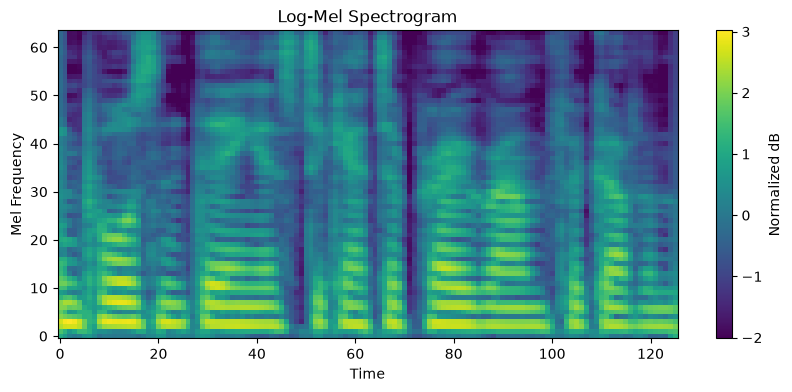

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.imshow(
    mel,
    origin="lower",
    aspect="auto"
)

plt.title("Log-Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.colorbar(label="Normalized dB")

plt.show()

In [35]:
import torch
from torch.utils.data import Dataset


class VoiceSpoofDataset(Dataset):

    def __init__(self, files, labels, training=False):
        self.files = files
        self.labels = labels
        self.training = training

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):

        file_path = self.files[index]
        label = self.labels[index]

        # Load 2-second audio
        audio = load_audio(
            file_path,
            training=self.training
        )

        # Convert to Log-Mel
        mel = audio_to_mel(audio)

        # CNN expects:
        # [channel, height, width]
        mel = torch.tensor(mel).unsqueeze(0)

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return mel, label

In [45]:
train_paths = []
train_labels = []

for label, files in train_files.items():

    for file in files:
        train_paths.append(file)

        if label == "bonafide":
            train_labels.append(0)
        else:
            train_labels.append(1)


dev_paths = []
dev_labels = []

for label, directory in {
    "bonafide": dev_bonafide_dir,
    "spoof": dev_spoof_dir
}.items():

    for file in directory.glob("*.flac"):
        dev_paths.append(file)

        if label == "bonafide":
            dev_labels.append(0)
        else:
            dev_labels.append(1)


print("Training:", len(train_paths))
print("Validation:", len(dev_paths))

Training: 200
Validation: 100


In [46]:
from torch.utils.data import DataLoader

train_dataset = VoiceSpoofDataset(
    train_paths,
    train_labels,
    training=True
)

dev_dataset = VoiceSpoofDataset(
    dev_paths,
    dev_labels,
    training=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Dev batches:", len(dev_loader))

Train batches: 13
Dev batches: 7


In [47]:
mel_batch, label_batch = next(iter(train_loader))

print("Mel batch shape:", mel_batch.shape)
print("Label batch shape:", label_batch.shape)
print("Labels:", label_batch[:10])

Mel batch shape: torch.Size([16, 1, 64, 126])
Label batch shape: torch.Size([16])
Labels: tensor([0., 0., 1., 0., 0., 1., 0., 0., 1., 0.])


In [48]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [49]:
import torch.nn as nn


class VoiceSpoofCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d((4, 8)),

            nn.Flatten(),

            nn.Linear(
                64 * 4 * 8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x.squeeze(1)

In [50]:
model = VoiceSpoofCNN().to(device)

print(model)

VoiceSpoofCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(4, 8))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Lin

In [51]:
with torch.no_grad():

    test_input = mel_batch.to(device)

    output = model(test_input)

print("Input shape:", test_input.shape)
print("Output shape:", output.shape)
print("Output:", output[:5])

Input shape: torch.Size([16, 1, 64, 126])
Output shape: torch.Size([16])
Output: tensor([ 0.1176, -0.2051,  0.1653,  0.0148,  0.4663])


In [52]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [53]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for mel, labels in loader:

        mel = mel.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(mel)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * len(labels)

        predictions = (
            torch.sigmoid(logits) >= 0.5
        ).float()

        correct += (
            predictions == labels
        ).sum().item()

        total += len(labels)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for mel, labels in loader:

            mel = mel.to(device)
            labels = labels.to(device)

            logits = model(mel)

            loss = criterion(logits, labels)

            total_loss += (
                loss.item() * len(labels)
            )

            probabilities = torch.sigmoid(logits)

            predictions = (
                probabilities >= 0.5
            ).int()

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    avg_loss = total_loss / len(all_labels)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [55]:
EPOCHS = 15

best_f1 = 0.0

history = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    metrics = evaluate(
        model,
        dev_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "dev_loss": metrics["loss"],
        "dev_accuracy": metrics["accuracy"],
        "dev_precision": metrics["precision"],
        "dev_recall": metrics["recall"],
        "dev_f1": metrics["f1"]
    })

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Dev Loss: {metrics['loss']:.4f} | "
        f"Dev Acc: {metrics['accuracy']:.3f} | "
        f"Dev F1: {metrics['f1']:.3f}"
    )

    # Save the best model
    if metrics["f1"] > best_f1:

        best_f1 = metrics["f1"]

        torch.save(
            model.state_dict(),
            "D:/DeepFake/best_voice_spoof_cnn.pt"
        )

Epoch 01/15 | Train Loss: 0.8238 | Train Acc: 0.565 | Dev Loss: 0.6675 | Dev Acc: 0.630 | Dev F1: 0.648
Epoch 02/15 | Train Loss: 0.7515 | Train Acc: 0.470 | Dev Loss: 0.6483 | Dev Acc: 0.630 | Dev F1: 0.684
Epoch 03/15 | Train Loss: 0.6716 | Train Acc: 0.620 | Dev Loss: 0.6466 | Dev Acc: 0.640 | Dev F1: 0.684
Epoch 04/15 | Train Loss: 0.6567 | Train Acc: 0.660 | Dev Loss: 0.6421 | Dev Acc: 0.660 | Dev F1: 0.660
Epoch 05/15 | Train Loss: 0.6363 | Train Acc: 0.675 | Dev Loss: 0.6341 | Dev Acc: 0.620 | Dev F1: 0.661
Epoch 06/15 | Train Loss: 0.6330 | Train Acc: 0.695 | Dev Loss: 0.6253 | Dev Acc: 0.640 | Dev F1: 0.673
Epoch 07/15 | Train Loss: 0.6498 | Train Acc: 0.630 | Dev Loss: 0.6226 | Dev Acc: 0.700 | Dev F1: 0.694
Epoch 08/15 | Train Loss: 0.6543 | Train Acc: 0.635 | Dev Loss: 0.6362 | Dev Acc: 0.660 | Dev F1: 0.707
Epoch 09/15 | Train Loss: 0.6341 | Train Acc: 0.705 | Dev Loss: 0.6166 | Dev Acc: 0.650 | Dev F1: 0.660
Epoch 10/15 | Train Loss: 0.6374 | Train Acc: 0.605 | Dev Loss: 

In [56]:
model.load_state_dict(
    torch.load(
        "D:/DeepFake/best_voice_spoof_cnn.pt",
        map_location=device
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


In [57]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


def get_predictions(model, loader, device):

    model.eval()

    labels = []
    predictions = []

    with torch.no_grad():

        for mel, y in loader:

            mel = mel.to(device)

            logits = model(mel)

            probs = torch.sigmoid(logits)

            pred = (
                probs >= 0.5
            ).int()

            labels.extend(y.numpy())
            predictions.extend(
                pred.cpu().numpy()
            )

    return labels, predictions


true_labels, predictions = get_predictions(
    model,
    dev_loader,
    device
)

cm = confusion_matrix(
    true_labels,
    predictions
)

print(cm)

[[31 19]
 [10 40]]


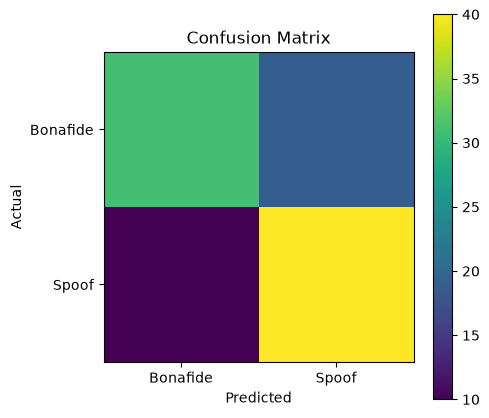

In [58]:
plt.figure(figsize=(5, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Bonafide", "Spoof"]
)

plt.yticks(
    [0, 1],
    ["Bonafide", "Spoof"]
)

plt.colorbar()

plt.show()

In [59]:
print("Confusion Matrix")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negative  (Bonafide → Bonafide):", tn)
print("False Positive (Bonafide → Spoof):", fp)
print("False Negative (Spoof → Bonafide):", fn)
print("True Positive  (Spoof → Spoof):", tp)

Confusion Matrix
[[31 19]
 [10 40]]

True Negative  (Bonafide → Bonafide): 31
False Positive (Bonafide → Spoof): 19
False Negative (Spoof → Bonafide): 10
True Positive  (Spoof → Spoof): 40


In [60]:
accuracy = (tn + tp) / (tn + fp + fn + tp)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0

recall = tp / (tp + fn) if (tp + fn) > 0 else 0

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"FPR      : {fpr:.4f}")
print(f"FNR      : {fnr:.4f}")

Accuracy : 0.7100
Precision: 0.6780
Recall   : 0.8000
FPR      : 0.3800
FNR      : 0.2000


In [61]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_probabilities(model, loader, device):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for mel, labels in loader:
            mel = mel.to(device)

            logits = model(mel)
            probs = torch.sigmoid(logits)

            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_probs)


dev_labels_np, dev_probs = get_probabilities(
    model,
    dev_loader,
    device
)

print("Number of validation samples:", len(dev_labels_np))
print("First 10 probabilities:", dev_probs[:10])

Number of validation samples: 100
First 10 probabilities: [0.41079065 0.41102913 0.29520568 0.6826459  0.4858828  0.3075304
 0.3015541  0.520274   0.28886703 0.57173556]


In [62]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    predictions = (
        dev_probs >= threshold
    ).astype(int)

    precision = precision_score(
        dev_labels_np,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        dev_labels_np,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        dev_labels_np,
        predictions,
        zero_division=0
    )

    accuracy = accuracy_score(
        dev_labels_np,
        predictions
    )

    threshold_results.append(
        (
            threshold,
            accuracy,
            precision,
            recall,
            f1
        )
    )

for result in threshold_results:
    print(
        f"Threshold={result[0]:.2f} | "
        f"Accuracy={result[1]:.3f} | "
        f"Precision={result[2]:.3f} | "
        f"Recall={result[3]:.3f} | "
        f"F1={result[4]:.3f}"
    )

Threshold=0.10 | Accuracy=0.500 | Precision=0.500 | Recall=1.000 | F1=0.667
Threshold=0.15 | Accuracy=0.500 | Precision=0.500 | Recall=1.000 | F1=0.667
Threshold=0.20 | Accuracy=0.500 | Precision=0.500 | Recall=1.000 | F1=0.667
Threshold=0.25 | Accuracy=0.500 | Precision=0.500 | Recall=1.000 | F1=0.667
Threshold=0.30 | Accuracy=0.550 | Precision=0.527 | Recall=0.980 | F1=0.685
Threshold=0.35 | Accuracy=0.640 | Precision=0.583 | Recall=0.980 | F1=0.731
Threshold=0.40 | Accuracy=0.660 | Precision=0.608 | Recall=0.900 | F1=0.726
Threshold=0.45 | Accuracy=0.670 | Precision=0.627 | Recall=0.840 | F1=0.718
Threshold=0.50 | Accuracy=0.710 | Precision=0.678 | Recall=0.800 | F1=0.734
Threshold=0.55 | Accuracy=0.670 | Precision=0.681 | Recall=0.640 | F1=0.660
Threshold=0.60 | Accuracy=0.680 | Precision=0.750 | Recall=0.540 | F1=0.628
Threshold=0.65 | Accuracy=0.690 | Precision=0.852 | Recall=0.460 | F1=0.597
Threshold=0.70 | Accuracy=0.680 | Precision=0.909 | Recall=0.400 | F1=0.556
Threshold=0.

In [63]:
import json

baseline = {
    "train_bonafide": 100,
    "train_spoof": 100,
    "dev_bonafide": 50,
    "dev_spoof": 50,
    "sample_rate": 16000,
    "segment_duration": 2,
    "n_mels": 64,
    "model": "VoiceSpoofCNN"
}

with open(
    "D:/DeepFake/baseline_v1.json",
    "w"
) as f:
    json.dump(
        baseline,
        f,
        indent=4
    )

print("Baseline information saved.")

Baseline information saved.


NEXT BIG DATA TRAINING- 500 BONAFIDE AND SPOOF EACH (FOR TRAIN) 200 BONAFIDE AND SPOOF EACH (FOR DEV)

In [64]:
from pathlib import Path

# Current files on disk
existing_train_bonafide = {
    p.stem for p in bonafide_dir.glob("*.flac")
}

existing_train_spoof = {
    p.stem for p in spoof_dir.glob("*.flac")
}

existing_dev_bonafide = {
    p.stem for p in dev_bonafide_dir.glob("*.flac")
}

existing_dev_spoof = {
    p.stem for p in dev_spoof_dir.glob("*.flac")
}


# Target V2 sizes
TARGET_TRAIN_PER_CLASS = 500
TARGET_DEV_PER_CLASS = 200


print("Current TRAIN:")
print("Bona-fide:", len(existing_train_bonafide))
print("Spoof:", len(existing_train_spoof))

print("\nCurrent DEV:")
print("Bona-fide:", len(existing_dev_bonafide))
print("Spoof:", len(existing_dev_spoof))


print("\nAdditional TRAIN needed:")
print(
    "Bona-fide:",
    max(0, TARGET_TRAIN_PER_CLASS - len(existing_train_bonafide))
)

print(
    "Spoof:",
    max(0, TARGET_TRAIN_PER_CLASS - len(existing_train_spoof))
)

print("\nAdditional DEV needed:")
print(
    "Bona-fide:",
    max(0, TARGET_DEV_PER_CLASS - len(existing_dev_bonafide))
)

print(
    "Spoof:",
    max(0, TARGET_DEV_PER_CLASS - len(existing_dev_spoof))
)

Current TRAIN:
Bona-fide: 100
Spoof: 100

Current DEV:
Bona-fide: 50
Spoof: 50

Additional TRAIN needed:
Bona-fide: 400
Spoof: 400

Additional DEV needed:
Bona-fide: 150
Spoof: 150


In [65]:
import random

random.seed(42)

unused_train_bonafide = [
    r for r in train_records
    if r["label"] == "bonafide"
    and r["audio_id"] not in existing_train_bonafide
]

unused_train_spoof = [
    r for r in train_records
    if r["label"] == "spoof"
    and r["audio_id"] not in existing_train_spoof
]


additional_train_bonafide = random.sample(
    unused_train_bonafide,
    TARGET_TRAIN_PER_CLASS - len(existing_train_bonafide)
)

additional_train_spoof = random.sample(
    unused_train_spoof,
    TARGET_TRAIN_PER_CLASS - len(existing_train_spoof)
)

additional_train_records = (
    additional_train_bonafide +
    additional_train_spoof
)

random.shuffle(additional_train_records)

print("NEW training files selected:",
      len(additional_train_records))

print(
    "New bona-fide:",
    sum(r["label"] == "bonafide"
        for r in additional_train_records)
)

print(
    "New spoof:",
    sum(r["label"] == "spoof"
        for r in additional_train_records)
)

NEW training files selected: 800
New bona-fide: 400
New spoof: 400


In [66]:
unused_dev_bonafide = [
    r for r in dev_records
    if r["label"] == "bonafide"
    and r["audio_id"] not in existing_dev_bonafide
]

unused_dev_spoof = [
    r for r in dev_records
    if r["label"] == "spoof"
    and r["audio_id"] not in existing_dev_spoof
]


additional_dev_bonafide = random.sample(
    unused_dev_bonafide,
    TARGET_DEV_PER_CLASS - len(existing_dev_bonafide)
)

additional_dev_spoof = random.sample(
    unused_dev_spoof,
    TARGET_DEV_PER_CLASS - len(existing_dev_spoof)
)

additional_dev_records = (
    additional_dev_bonafide +
    additional_dev_spoof
)

random.shuffle(additional_dev_records)

print("NEW validation files selected:",
      len(additional_dev_records))

print(
    "New bona-fide:",
    sum(r["label"] == "bonafide"
        for r in additional_dev_records)
)

print(
    "New spoof:",
    sum(r["label"] == "spoof"
        for r in additional_dev_records)
)

NEW validation files selected: 300
New bona-fide: 150
New spoof: 150


In [67]:
import pandas as pd

additional_train_df = pd.DataFrame(additional_train_records)
additional_dev_df = pd.DataFrame(additional_dev_records)

additional_train_manifest = (
    "D:/DeepFake/data/asvspoof2019/"
    "additional_train_v2.csv"
)

additional_dev_manifest = (
    "D:/DeepFake/data/asvspoof2019/"
    "additional_dev_v2.csv"
)

additional_train_df.to_csv(
    additional_train_manifest,
    index=False
)

additional_dev_df.to_csv(
    additional_dev_manifest,
    index=False
)

print("Train manifest:", additional_train_manifest)
print("Dev manifest:", additional_dev_manifest)

print("\nNew TRAIN:", len(additional_train_df))
print("New DEV:", len(additional_dev_df))

Train manifest: D:/DeepFake/data/asvspoof2019/additional_train_v2.csv
Dev manifest: D:/DeepFake/data/asvspoof2019/additional_dev_v2.csv

New TRAIN: 800
New DEV: 300


In [68]:
print("Current TRAIN")
print("Bona-fide:", len(list(bonafide_dir.glob("*.flac"))))
print("Spoof:", len(list(spoof_dir.glob("*.flac"))))

print("\nCurrent DEV")
print("Bona-fide:", len(list(dev_bonafide_dir.glob("*.flac"))))
print("Spoof:", len(list(dev_spoof_dir.glob("*.flac"))))

Current TRAIN
Bona-fide: 100
Spoof: 100

Current DEV
Bona-fide: 50
Spoof: 50


In [73]:
import kagglehub
import shutil
import time
from pathlib import Path
from tqdm.auto import tqdm


def download_records(records, description):

    failed = []

    for r in tqdm(records, desc=description):

        audio_id = r["audio_id"]
        label = r["label"]

        if label == "bonafide":
            destination_dir = bonafide_dir
        else:
            destination_dir = spoof_dir

        destination_file = destination_dir / f"{audio_id}.flac"

        # Safety check: skip if it already exists
        if destination_file.exists():
            continue

        kaggle_path = (
            f"LA/LA/ASVspoof2019_LA_train/"
            f"flac/{audio_id}.flac"
        )

        success = False

        for attempt in range(1, 4):

            try:

                downloaded_path = kagglehub.dataset_download(
                    "awsaf49/asvpoof-2019-dataset",
                    path=kaggle_path,
                    output_dir=str(download_root)
                )

                downloaded_path = Path(downloaded_path)

                if not downloaded_path.exists():
                    raise FileNotFoundError(
                        f"Downloaded file not found: {downloaded_path}"
                    )

                shutil.copy2(
                    downloaded_path,
                    destination_file
                )

                success = True
                break

            except Exception as e:

                print(
                    f"\n{audio_id} failed "
                    f"(attempt {attempt}/3): "
                    f"{type(e).__name__}: {e}"
                )

                if attempt < 3:
                    time.sleep(5)

        if not success:
            failed.append(r)

    print("\nDownload pass complete.")
    print("Requested:", len(records))
    print("Failed:", len(failed))

    return failed

In [74]:
failed_train_v2 = download_records(
    remaining_train_v2,
    "TRAIN V2 RESUME"
)

TRAIN V2 RESUME:   0%|          | 0/389 [00:00<?, ?it/s]


LA_T_8629332 failed (attempt 1/3): FileExistsError: File already exists at output_dir: D:\DeepFake\data\asvspoof2019\_downloads_v2\LA/LA/ASVspoof2019_LA_train/flac/LA_T_8629332.flac. Set force_download=True to replace it.

LA_T_8629332 failed (attempt 2/3): FileExistsError: File already exists at output_dir: D:\DeepFake\data\asvspoof2019\_downloads_v2\LA/LA/ASVspoof2019_LA_train/flac/LA_T_8629332.flac. Set force_download=True to replace it.


TRAIN V2 RESUME:   0%|          | 1/389 [00:20<2:11:27, 20.33s/it]


LA_T_8629332 failed (attempt 3/3): FileExistsError: File already exists at output_dir: D:\DeepFake\data\asvspoof2019\_downloads_v2\LA/LA/ASVspoof2019_LA_train/flac/LA_T_8629332.flac. Set force_download=True to replace it.


100%|██████████| 56.5k/56.5k [00:00<00:00, 58.9kB/s]
TRAIN V2 RESUME:   1%|          | 2/389 [00:30<1:32:22, 14.32s/it]

...

100%|██████████| 59.6k/59.6k [00:00<00:00, 102kB/s]
TRAIN V2 RESUME:  79%|███████▊  | 306/389 [45:39<10:53,  7.88s/it]

100%|██████████| 57.4k/57.4k [00:01<00:00, 52.9kB/s]
TRAIN V2 RESUME:  79%|███████▉  | 307/389 [45:46<10:25,  7.63s/it]

100%|██████████| 68.5k/68.5k [00:01<00:00, 61.9kB/s]
TRAIN V2 RESUME:  79%|███████▉  | 308/389 [45:57<11:34,  8.58s/it]

100%|██████████| 87.7k/87.7k [00:01<00:00, 86.6kB/s]
TRAIN V2 RESUME:  79%|███████▉  | 309/389 [46:14<11:58,  8.98s/it]


KeyboardInterrupt: 

In [75]:
print("Bona-fide:",
      len(list(bonafide_dir.glob("*.flac"))))

print("Spoof:",
      len(list(spoof_dir.glob("*.flac"))))

print("Total:",
      len(list(bonafide_dir.glob("*.flac"))) +
      len(list(spoof_dir.glob("*.flac"))))

Bona-fide: 462
Spoof: 457
Total: 919


In [76]:
existing_train_ids = {
    p.stem
    for p in bonafide_dir.glob("*.flac")
}

existing_train_ids.update(
    p.stem
    for p in spoof_dir.glob("*.flac")
)

remaining_train_v2 = [
    r
    for r in additional_train_records
    if r["audio_id"] not in existing_train_ids
]

print("Already downloaded:", len(existing_train_ids))
print("Still needed:", len(remaining_train_v2))

print(
    "Remaining bona-fide:",
    sum(r["label"] == "bonafide" for r in remaining_train_v2)
)

print(
    "Remaining spoof:",
    sum(r["label"] == "spoof" for r in remaining_train_v2)
)

Already downloaded: 919
Still needed: 81
Remaining bona-fide: 38
Remaining spoof: 43


In [77]:
import kagglehub
import shutil
import time
from pathlib import Path
from tqdm.auto import tqdm


def download_remaining(records, description):

    failed = []

    for r in tqdm(records, desc=description):

        audio_id = r["audio_id"]
        label = r["label"]

        # Decide destination
        if label == "bonafide":
            destination_dir = bonafide_dir
        else:
            destination_dir = spoof_dir

        destination_file = destination_dir / f"{audio_id}.flac"

        # ------------------------------------------------
        # IMPORTANT:
        # Skip anything that was already downloaded
        # ------------------------------------------------
        if destination_file.exists():
            continue

        kaggle_path = (
            f"LA/LA/ASVspoof2019_LA_train/"
            f"flac/{audio_id}.flac"
        )

        success = False

        for attempt in range(1, 4):

            try:

                downloaded_path = kagglehub.dataset_download(
                    "awsaf49/asvpoof-2019-dataset",
                    path=kaggle_path,
                    output_dir=str(download_root)
                )

                downloaded_path = Path(downloaded_path)

                if not downloaded_path.exists():
                    raise FileNotFoundError(
                        f"File not found: {downloaded_path}"
                    )

                shutil.copy2(
                    downloaded_path,
                    destination_file
                )

                success = True
                break

            except Exception as e:

                print(
                    f"\n{audio_id} failed "
                    f"(attempt {attempt}/3): "
                    f"{type(e).__name__}: {e}"
                )

                if attempt < 3:
                    time.sleep(5)

        if not success:
            failed.append(r)

    print("\nDownload pass complete.")
    print("Requested:", len(records))
    print("Failed:", len(failed))

    return failed

In [78]:
failed_remaining = download_remaining(
    remaining_train_v2,
    "FINAL 81 DOWNLOAD"
)

FINAL 81 DOWNLOAD:   0%|          | 0/81 [00:00<?, ?it/s]


LA_T_8629332 failed (attempt 1/3): FileExistsError: File already exists at output_dir: D:\DeepFake\data\asvspoof2019\_downloads_v2\LA/LA/ASVspoof2019_LA_train/flac/LA_T_8629332.flac. Set force_download=True to replace it.

LA_T_8629332 failed (attempt 2/3): FileExistsError: File already exists at output_dir: D:\DeepFake\data\asvspoof2019\_downloads_v2\LA/LA/ASVspoof2019_LA_train/flac/LA_T_8629332.flac. Set force_download=True to replace it.


FINAL 81 DOWNLOAD:   1%|          | 1/81 [00:16<21:53, 16.42s/it]


LA_T_8629332 failed (attempt 3/3): FileExistsError: File already exists at output_dir: D:\DeepFake\data\asvspoof2019\_downloads_v2\LA/LA/ASVspoof2019_LA_train/flac/LA_T_8629332.flac. Set force_download=True to replace it.


100%|██████████| 70.8k/70.8k [00:00<00:00, 100kB/s]
FINAL 81 DOWNLOAD:   2%|▏         | 2/81 [00:22<13:28, 10.23s/it]

...

100%|██████████| 43.2k/43.2k [00:00<00:00, 19.3MB/s]
FINAL 81 DOWNLOAD:  96%|█████████▋| 78/81 [08:58<00:21,  7.30s/it]

100%|██████████| 87.7k/87.7k [00:01<00:00, 71.5kB/s]
FINAL 81 DOWNLOAD:  98%|█████████▊| 79/81 [09:05<00:14,  7.20s/it]

100%|██████████| 68.5k/68.5k [00:01<00:00, 61.7kB/s]
FINAL 81 DOWNLOAD:  99%|█████████▉| 80/81 [09:12<00:07,  7.14s/it]

100%|██████████| 77.5k/77.5k [00:01<00:00, 57.8kB/s]
FINAL 81 DOWNLOAD: 100%|██████████| 81/81 [09:19<00:00,  6.91s/it]


Download pass complete.
Requested: 81
Failed: 1


In [79]:
print("Bona-fide:",
      len(list(bonafide_dir.glob("*.flac"))))

print("Spoof:",
      len(list(spoof_dir.glob("*.flac"))))

print("Total:",
      len(list(bonafide_dir.glob("*.flac"))) +
      len(list(spoof_dir.glob("*.flac"))))

print("Failed records:", len(failed_remaining))

for r in failed_remaining:
    print(r)

Bona-fide: 500
Spoof: 499
Total: 999
Failed records: 1
{'speaker_id': 'LA_0098', 'audio_id': 'LA_T_8629332', 'label': 'spoof'}


In [80]:
from pathlib import Path

temp_file = (
    download_root
    / "LA"
    / "LA"
    / "ASVspoof2019_LA_train"
    / "flac"
    / "LA_T_8629332.flac"
)

print("Temporary file exists:", temp_file.exists())

if temp_file.exists():
    print("Size:", temp_file.stat().st_size, "bytes")

Temporary file exists: True
Size: 0 bytes


In [81]:
import shutil

destination_file = spoof_dir / "LA_T_8629332.flac"

shutil.copy2(temp_file, destination_file)

print("Copied:", destination_file)

Copied: D:\DeepFake\data\asvspoof2019\train\spoof\LA_T_8629332.flac


In [82]:
from pathlib import Path

bad_file = spoof_dir / "LA_T_8629332.flac"

if bad_file.exists():
    bad_file.unlink()

print("Exists after deletion:", bad_file.exists())

Exists after deletion: False


In [83]:
if temp_file.exists():
    temp_file.unlink()

print("Temporary file exists:", temp_file.exists())

Temporary file exists: False


In [84]:
import kagglehub
from pathlib import Path
import shutil

single_download_root = Path(
    "D:/DeepFake/data/asvspoof2019/single_retry"
)

single_download_root.mkdir(
    parents=True,
    exist_ok=True
)

kaggle_path = (
    "LA/LA/ASVspoof2019_LA_train/"
    "flac/LA_T_8629332.flac"
)

downloaded_path = kagglehub.dataset_download(
    "awsaf49/asvpoof-2019-dataset",
    path=kaggle_path,
    output_dir=str(single_download_root)
)

print("Downloaded path:", downloaded_path)

100%|██████████| 67.9k/67.9k [00:00<00:00, 76.1kB/s]

Downloaded path: D:\DeepFake\data\asvspoof2019\single_retry\LA/LA/ASVspoof2019_LA_train/flac/LA_T_8629332.flac


In [85]:
downloaded_path = Path(downloaded_path)

print("Exists:", downloaded_path.exists())
print("Size:", downloaded_path.stat().st_size, "bytes")

Exists: True
Size: 69484 bytes


In [86]:
shutil.copy2(
    downloaded_path,
    spoof_dir / "LA_T_8629332.flac"
)

print("Copied successfully.")

Copied successfully.


In [87]:
print("Bona-fide:",
      len(list(bonafide_dir.glob("*.flac"))))

print("Spoof:",
      len(list(spoof_dir.glob("*.flac"))))

print("Total:",
      len(list(bonafide_dir.glob("*.flac"))) +
      len(list(spoof_dir.glob("*.flac"))))

Bona-fide: 500
Spoof: 500
Total: 1000


In [88]:
import soundfile as sf

all_train_files = (
    list(bonafide_dir.glob("*.flac")) +
    list(spoof_dir.glob("*.flac"))
)

bad_files = []
sample_rates = set()
durations = []

for file in all_train_files:
    try:
        info = sf.info(file)

        if info.frames == 0:
            bad_files.append(file)
            continue

        sample_rates.add(info.samplerate)
        durations.append(info.frames / info.samplerate)

    except Exception:
        bad_files.append(file)

print("Total files checked:", len(all_train_files))
print("Bad files:", len(bad_files))
print("Sample rates:", sample_rates)

print(
    "Average duration:",
    sum(durations) / len(durations),
    "seconds"
)

print(
    "Minimum duration:",
    min(durations),
    "seconds"
)

print(
    "Maximum duration:",
    max(durations),
    "seconds"
)

if bad_files:
    print("\nBad files:")
    for f in bad_files:
        print(f)

Total files checked: 1000
Bad files: 0
Sample rates: {16000}
Average duration: 3.3939484375 seconds
Minimum duration: 0.744875 seconds
Maximum duration: 9.338625 seconds


In [89]:
import pandas as pd
from pathlib import Path

# Read the ASVspoof training protocol
records = []

with open(train_protocol, "r") as f:
    for line in f:
        parts = line.split()

        if len(parts) >= 5:
            speaker_id = parts[0]
            audio_id = parts[1]
            label = parts[4]

            if label in ("bonafide", "spoof"):
                records.append({
                    "speaker_id": speaker_id,
                    "audio_id": audio_id,
                    "label": label
                })

protocol_df = pd.DataFrame(records)

# All audio files we actually downloaded
audio_files = (
    list(bonafide_dir.glob("*.flac")) +
    list(spoof_dir.glob("*.flac"))
)

audio_df = pd.DataFrame({
    "audio_id": [p.stem for p in audio_files],
    "path": [str(p) for p in audio_files]
})

# Match downloaded audio with protocol information
manifest = audio_df.merge(
    protocol_df,
    on="audio_id",
    how="inner"
)

print("Downloaded audio files:", len(audio_df))
print("Matched files:", len(manifest))

print("\nClass distribution:")
print(manifest["label"].value_counts())

print("\nUnique speakers:")
print(manifest["speaker_id"].nunique())

print("\nFirst 5 rows:")
print(manifest.head())

Downloaded audio files: 1000
Matched files: 1000

Class distribution:
label
bonafide    500
spoof       500
Name: count, dtype: int64

Unique speakers:
20

First 5 rows:
       audio_id                                               path speaker_id  \
0  LA_T_1013597  D:\DeepFake\data\asvspoof2019\train\bonafide\L...    LA_0086   
1  LA_T_1052701  D:\DeepFake\data\asvspoof2019\train\bonafide\L...    LA_0094   
2  LA_T_1126222  D:\DeepFake\data\asvspoof2019\train\bonafide\L...    LA_0083   
3  LA_T_1130924  D:\DeepFake\data\asvspoof2019\train\bonafide\L...    LA_0087   
4  LA_T_1186717  D:\DeepFake\data\asvspoof2019\train\bonafide\L...    LA_0086   

      label  
0  bonafide  
1  bonafide  
2  bonafide  
3  bonafide  
4  bonafide  


CLASSIFYING STARTS

In [90]:
existing_dev_ids = {
    p.stem
    for p in dev_bonafide_dir.glob("*.flac")
}

existing_dev_ids.update(
    p.stem
    for p in dev_spoof_dir.glob("*.flac")
)

print("Existing DEV files:", len(existing_dev_ids))

Existing DEV files: 100


In [91]:
import random

random.seed(42)

unused_dev_bonafide = [
    r for r in dev_records
    if r["label"] == "bonafide"
    and r["audio_id"] not in existing_dev_ids
]

unused_dev_spoof = [
    r for r in dev_records
    if r["label"] == "spoof"
    and r["audio_id"] not in existing_dev_ids
]

additional_dev_bonafide = random.sample(
    unused_dev_bonafide,
    150
)

additional_dev_spoof = random.sample(
    unused_dev_spoof,
    150
)

additional_dev_records = (
    additional_dev_bonafide +
    additional_dev_spoof
)

random.shuffle(additional_dev_records)

print("New DEV selected:", len(additional_dev_records))
print(
    "New bona-fide:",
    sum(r["label"] == "bonafide"
        for r in additional_dev_records)
)
print(
    "New spoof:",
    sum(r["label"] == "spoof"
        for r in additional_dev_records)
)

New DEV selected: 300
New bona-fide: 150
New spoof: 150


In [92]:
import pandas as pd

additional_dev_df = pd.DataFrame(
    additional_dev_records
)

additional_dev_manifest = (
    "D:/DeepFake/data/asvspoof2019/"
    "additional_dev_v2.csv"
)

additional_dev_df.to_csv(
    additional_dev_manifest,
    index=False
)

print("Saved:", additional_dev_manifest)

Saved: D:/DeepFake/data/asvspoof2019/additional_dev_v2.csv


In [93]:
import kagglehub
import shutil
import time
from pathlib import Path
from tqdm.auto import tqdm

dev_download_root = Path(
    "D:/DeepFake/data/asvspoof2019/dev/_downloads_v2"
)

dev_download_root.mkdir(
    parents=True,
    exist_ok=True
)

failed_dev_v2 = []

for r in tqdm(
    additional_dev_records,
    desc="DEV V2 DOWNLOAD"
):

    audio_id = r["audio_id"]
    label = r["label"]

    destination_dir = (
        dev_bonafide_dir
        if label == "bonafide"
        else dev_spoof_dir
    )

    destination_file = (
        destination_dir / f"{audio_id}.flac"
    )

    # Never download an existing file
    if destination_file.exists():
        continue

    kaggle_path = (
        "LA/LA/ASVspoof2019_LA_dev/"
        f"flac/{audio_id}.flac"
    )

    success = False

    # Unique directory for this particular file
    file_download_dir = (
        dev_download_root / audio_id
    )

    file_download_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    for attempt in range(1, 4):

        try:

            downloaded_path = kagglehub.dataset_download(
                "awsaf49/asvpoof-2019-dataset",
                path=kaggle_path,
                output_dir=str(file_download_dir)
            )

            downloaded_path = Path(
                downloaded_path
            )

            if (
                not downloaded_path.exists()
                or downloaded_path.stat().st_size == 0
            ):
                raise RuntimeError(
                    "Downloaded file is missing or empty."
                )

            shutil.copy2(
                downloaded_path,
                destination_file
            )

            success = True
            break

        except Exception as e:

            print(
                f"\n{audio_id} "
                f"(attempt {attempt}/3): "
                f"{type(e).__name__}: {e}"
            )

            if attempt < 3:
                time.sleep(5)

    if not success:
        failed_dev_v2.append(r)

print("\nDEV download finished.")
print("Failed:", len(failed_dev_v2))

DEV V2 DOWNLOAD:   0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 125k/125k [00:01<00:00, 71.8kB/s]
DEV V2 DOWNLOAD:   0%|          | 1/300 [00:08<41:24,  8.31s/it]

100%|██████████| 38.4k/38.4k [00:00<00:00, 67.9kB/s]
DEV V2 DOWNLOAD:   1%|          | 2/300 [00:15<39:25,  7.94s/it]

100%|██████████| 35.1k/35.1k [00:00<00:00, 36.1kB/s]
DEV V2 DOWNLOAD:   1%|          | 3/300 [00:22<35:02,  7.08s/it]

100%|██████████| 68.8k/68.8k [00:01<00:00, 38.2kB/s]
DEV V2 DOWNLOAD:   1%|▏         | 4/300 [00:31<38:57,  7.90s/it]

...

100%|██████████| 51.8k/51.8k [00:00<00:00, 79.1kB/s]
DEV V2 DOWNLOAD:  87%|████████▋ | 260/300 [30:24<05:07,  7.69s/it]

100%|██████████| 64.1k/64.1k [00:00<00:00, 80.8kB/s]
DEV V2 DOWNLOAD:  87%|████████▋ | 261/300 [30:33<05:09,  7.94s/it]

100%|██████████| 30.3k/30.3k [00:00<00:00, 66.9kB/s]
DEV V2 DOWNLOAD:  87%|████████▋ | 262/300 [30:41<05:02,  7.96s/it]

100%|██████████| 44.6k/44.6k [00:00<00:00, 130kB/s]
DEV V2 DOWNLOAD:  88%|████████▊ | 263/300 [30:49<04:20,  7.03s/it]


KeyboardInterrupt: 

In [94]:
print("DEV bona-fide:",
      len(list(dev_bonafide_dir.glob("*.flac"))))

print("DEV spoof:",
      len(list(dev_spoof_dir.glob("*.flac"))))

print("DEV total:",
      len(list(dev_bonafide_dir.glob("*.flac"))) +
      len(list(dev_spoof_dir.glob("*.flac"))))

DEV bona-fide: 184
DEV spoof: 179
DEV total: 363


In [95]:
existing_dev_ids = {
    p.stem
    for p in dev_bonafide_dir.glob("*.flac")
}

existing_dev_ids.update(
    p.stem
    for p in dev_spoof_dir.glob("*.flac")
)

remaining_dev_v2 = [
    r
    for r in additional_dev_records
    if r["audio_id"] not in existing_dev_ids
]

print("Original additional DEV selection:", len(additional_dev_records))
print("Already downloaded:", 
      len(additional_dev_records) - len(remaining_dev_v2))
print("Missing:", len(remaining_dev_v2))

print(
    "Missing bona-fide:",
    sum(r["label"] == "bonafide"
        for r in remaining_dev_v2)
)

print(
    "Missing spoof:",
    sum(r["label"] == "spoof"
        for r in remaining_dev_v2)
)

print("\nMissing IDs:")
for r in remaining_dev_v2:
    print(r["audio_id"], r["label"])

Original additional DEV selection: 300
Already downloaded: 263
Missing: 37
Missing bona-fide: 16
Missing spoof: 21

Missing IDs:
LA_D_2631213 spoof
LA_D_2614994 spoof
LA_D_6198995 bonafide
LA_D_6710328 bonafide
LA_D_1634113 spoof
LA_D_4386823 bonafide
LA_D_9864113 bonafide
LA_D_3286040 spoof
LA_D_6570467 spoof
LA_D_6748977 spoof
LA_D_1005971 spoof
LA_D_6518159 bonafide
LA_D_4141301 spoof
LA_D_6292396 spoof
LA_D_4463495 bonafide
LA_D_3678117 spoof
LA_D_4675196 bonafide
LA_D_5945817 bonafide
LA_D_5897153 spoof
LA_D_1454984 spoof
LA_D_4256004 spoof
LA_D_5774989 bonafide
LA_D_6547828 spoof
LA_D_2053527 bonafide
LA_D_2363836 bonafide
LA_D_2120805 spoof
LA_D_4881390 bonafide
LA_D_4866981 bonafide
LA_D_9955951 spoof
LA_D_2839116 spoof
LA_D_3464373 spoof
LA_D_8589204 spoof
LA_D_8073490 bonafide
LA_D_7089929 bonafide
LA_D_7674503 spoof
LA_D_6593270 bonafide
LA_D_2425743 spoof


In [96]:
existing_dev_ids = {
    p.stem
    for p in dev_bonafide_dir.glob("*.flac")
}

existing_dev_ids.update(
    p.stem
    for p in dev_spoof_dir.glob("*.flac")
)

# Also exclude the currently missing IDs so we don't retry them
problem_ids = {
    r["audio_id"]
    for r in remaining_dev_v2
}

available_bonafide = [
    r for r in dev_records
    if r["label"] == "bonafide"
    and r["audio_id"] not in existing_dev_ids
    and r["audio_id"] not in problem_ids
]

available_spoof = [
    r for r in dev_records
    if r["label"] == "spoof"
    and r["audio_id"] not in existing_dev_ids
    and r["audio_id"] not in problem_ids
]

replacement_bonafide = random.sample(
    available_bonafide,
    16
)

replacement_spoof = random.sample(
    available_spoof,
    21
)

replacement_dev_records = (
    replacement_bonafide +
    replacement_spoof
)

random.shuffle(replacement_dev_records)

print("Replacement files:", len(replacement_dev_records))
print(
    "Bona-fide:",
    sum(r["label"] == "bonafide"
        for r in replacement_dev_records)
)
print(
    "Spoof:",
    sum(r["label"] == "spoof"
        for r in replacement_dev_records)
)

Replacement files: 37
Bona-fide: 16
Spoof: 21


In [97]:
replacement_dev_df = pd.DataFrame(
    replacement_dev_records
)

replacement_dev_df.to_csv(
    "D:/DeepFake/data/asvspoof2019/replacement_dev_v2.csv",
    index=False
)

print("Replacement manifest saved.")

Replacement manifest saved.


In [98]:
existing_dev_ids = {
    p.stem
    for p in dev_bonafide_dir.glob("*.flac")
}

existing_dev_ids.update(
    p.stem
    for p in dev_spoof_dir.glob("*.flac")
)

remaining_dev_v2 = [
    r
    for r in additional_dev_records
    if r["audio_id"] not in existing_dev_ids
]

print("Additional DEV originally selected:", len(additional_dev_records))
print("Already present:", 
      len(additional_dev_records) - len(remaining_dev_v2))
print("Missing:", len(remaining_dev_v2))

print("\nMissing files:")
for r in remaining_dev_v2:
    print(r["audio_id"], "→", r["label"])

Additional DEV originally selected: 300
Already present: 263
Missing: 37

Missing files:
LA_D_2631213 → spoof
LA_D_2614994 → spoof
LA_D_6198995 → bonafide
LA_D_6710328 → bonafide
LA_D_1634113 → spoof
LA_D_4386823 → bonafide
LA_D_9864113 → bonafide
LA_D_3286040 → spoof
LA_D_6570467 → spoof
LA_D_6748977 → spoof
LA_D_1005971 → spoof
LA_D_6518159 → bonafide
LA_D_4141301 → spoof
LA_D_6292396 → spoof
LA_D_4463495 → bonafide
LA_D_3678117 → spoof
LA_D_4675196 → bonafide
LA_D_5945817 → bonafide
LA_D_5897153 → spoof
LA_D_1454984 → spoof
LA_D_4256004 → spoof
LA_D_5774989 → bonafide
LA_D_6547828 → spoof
LA_D_2053527 → bonafide
LA_D_2363836 → bonafide
LA_D_2120805 → spoof
LA_D_4881390 → bonafide
LA_D_4866981 → bonafide
LA_D_9955951 → spoof
LA_D_2839116 → spoof
LA_D_3464373 → spoof
LA_D_8589204 → spoof
LA_D_8073490 → bonafide
LA_D_7089929 → bonafide
LA_D_7674503 → spoof
LA_D_6593270 → bonafide
LA_D_2425743 → spoof


In [99]:
print("Replacement records:", len(replacement_dev_records))

print(
    "Replacement bona-fide:",
    sum(r["label"] == "bonafide"
        for r in replacement_dev_records)
)

print(
    "Replacement spoof:",
    sum(r["label"] == "spoof"
        for r in replacement_dev_records)
)

Replacement records: 37
Replacement bona-fide: 16
Replacement spoof: 21


In [100]:
import kagglehub
import shutil
import time
from pathlib import Path
from tqdm.auto import tqdm

replacement_download_root = Path(
    "D:/DeepFake/data/asvspoof2019/dev/replacement_downloads"
)

replacement_download_root.mkdir(
    parents=True,
    exist_ok=True
)

failed_replacements = []

for r in tqdm(
    replacement_dev_records,
    desc="DEV REPLACEMENTS"
):

    audio_id = r["audio_id"]
    label = r["label"]

    destination_dir = (
        dev_bonafide_dir
        if label == "bonafide"
        else dev_spoof_dir
    )

    destination_file = (
        destination_dir / f"{audio_id}.flac"
    )

    # Never download an existing file
    if destination_file.exists():
        continue

    temp_dir = replacement_download_root / audio_id
    temp_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    kaggle_path = (
        "LA/LA/ASVspoof2019_LA_dev/"
        f"flac/{audio_id}.flac"
    )

    success = False

    for attempt in range(1, 4):

        try:
            downloaded_path = kagglehub.dataset_download(
                "awsaf49/asvpoof-2019-dataset",
                path=kaggle_path,
                output_dir=str(temp_dir)
            )

            downloaded_path = Path(downloaded_path)

            if (
                not downloaded_path.exists()
                or downloaded_path.stat().st_size == 0
            ):
                raise RuntimeError(
                    "Downloaded file is missing or empty."
                )

            shutil.copy2(
                downloaded_path,
                destination_file
            )

            success = True
            break

        except Exception as e:

            print(
                f"\n{audio_id} - "
                f"attempt {attempt}/3: "
                f"{type(e).__name__}: {e}"
            )

            if attempt < 3:
                time.sleep(5)

    if not success:
        failed_replacements.append(r)

print("\nReplacement download complete.")
print("Failed:", len(failed_replacements))

DEV REPLACEMENTS:   0%|          | 0/37 [00:00<?, ?it/s]

100%|██████████| 92.9k/92.9k [00:01<00:00, 59.6kB/s]
DEV REPLACEMENTS:   3%|▎         | 1/37 [00:08<04:54,  8.19s/it]

100%|██████████| 43.6k/43.6k [00:00<00:00, 67.3kB/s]
DEV REPLACEMENTS:   5%|▌         | 2/37 [00:17<05:03,  8.68s/it]

100%|██████████| 48.7k/48.7k [00:00<00:00, 87.4kB/s]
DEV REPLACEMENTS:   8%|▊         | 3/37 [00:27<05:16,  9.32s/it]

100%|██████████| 36.1k/36.1k [00:00<00:00, 85.1kB/s]
DEV REPLACEMENTS:  11%|█         | 4/37 [00:37<05:20,  9.71s/it]

...

100%|██████████| 48.9k/48.9k [00:00<00:00, 58.1kB/s]
DEV REPLACEMENTS:  92%|█████████▏| 34/37 [05:24<00:26,  8.97s/it]

100%|██████████| 56.3k/56.3k [00:00<00:00, 99.5kB/s]
DEV REPLACEMENTS:  95%|█████████▍| 35/37 [05:35<00:19,  9.61s/it]

100%|██████████| 47.9k/47.9k [00:00<00:00, 142kB/s]
DEV REPLACEMENTS:  97%|█████████▋| 36/37 [05:43<00:09,  9.03s/it]

100%|██████████| 49.8k/49.8k [00:00<00:00, 89.9kB/s]
DEV REPLACEMENTS: 100%|██████████| 37/37 [05:53<00:00,  9.55s/it]


Replacement download complete.
Failed: 0


In [101]:
print(
    "DEV bona-fide:",
    len(list(dev_bonafide_dir.glob("*.flac")))
)

print(
    "DEV spoof:",
    len(list(dev_spoof_dir.glob("*.flac")))
)

print(
    "DEV total:",
    len(list(dev_bonafide_dir.glob("*.flac"))) +
    len(list(dev_spoof_dir.glob("*.flac")))
)

print(
    "Failed replacements:",
    len(failed_replacements)
)

DEV bona-fide: 200
DEV spoof: 200
DEV total: 400
Failed replacements: 0


In [102]:
import pandas as pd
from pathlib import Path

train_manifest = []

for label, directory in {
    "bonafide": bonafide_dir,
    "spoof": spoof_dir
}.items():

    for file in directory.glob("*.flac"):
        train_manifest.append({
            "audio_id": file.stem,
            "path": str(file),
            "label": label,
            "label_id": 0 if label == "bonafide" else 1
        })

dev_manifest = []

for label, directory in {
    "bonafide": dev_bonafide_dir,
    "spoof": dev_spoof_dir
}.items():

    for file in directory.glob("*.flac"):
        dev_manifest.append({
            "audio_id": file.stem,
            "path": str(file),
            "label": label,
            "label_id": 0 if label == "bonafide" else 1
        })

train_df = pd.DataFrame(train_manifest)
dev_df = pd.DataFrame(dev_manifest)

print("TRAIN")
print("Total:", len(train_df))
print(train_df["label"].value_counts())

print("\nDEV")
print("Total:", len(dev_df))
print(dev_df["label"].value_counts())

TRAIN
Total: 1000
label
bonafide    500
spoof       500
Name: count, dtype: int64

DEV
Total: 400
label
bonafide    200
spoof       200
Name: count, dtype: int64


In [103]:
train_ids = set(train_df["audio_id"])
dev_ids = set(dev_df["audio_id"])

overlap = train_ids.intersection(dev_ids)

print("Train IDs:", len(train_ids))
print("Dev IDs:", len(dev_ids))
print("Overlap:", len(overlap))

if overlap:
    print("Overlapping IDs:")
    print(list(overlap)[:20])
else:
    print("No train/dev audio ID overlap.")

Train IDs: 1000
Dev IDs: 400
Overlap: 0
No train/dev audio ID overlap.


In [104]:
train_df.to_csv(
    "D:/DeepFake/data/asvspoof2019/final_train_manifest.csv",
    index=False
)

dev_df.to_csv(
    "D:/DeepFake/data/asvspoof2019/final_dev_manifest.csv",
    index=False
)

print("Final manifests saved.")

Final manifests saved.


In [105]:
train_paths = [
    Path(p) for p in train_df["path"]
]

train_labels = train_df["label_id"].tolist()

dev_paths = [
    Path(p) for p in dev_df["path"]
]

dev_labels = dev_df["label_id"].tolist()

print("Train:", len(train_paths))
print("Dev:", len(dev_paths))

Train: 1000
Dev: 400


In [106]:
train_dataset_v2 = VoiceSpoofDataset(
    train_paths,
    train_labels,
    training=True
)

dev_dataset_v2 = VoiceSpoofDataset(
    dev_paths,
    dev_labels,
    training=False
)

train_loader_v2 = DataLoader(
    train_dataset_v2,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

dev_loader_v2 = DataLoader(
    dev_dataset_v2,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader_v2))
print("Dev batches:", len(dev_loader_v2))

Train batches: 63
Dev batches: 25


In [107]:
mel_batch_v2, label_batch_v2 = next(iter(train_loader_v2))

print("Mel batch:", mel_batch_v2.shape)
print("Labels:", label_batch_v2.shape)
print("First labels:", label_batch_v2[:10])

Mel batch: torch.Size([16, 1, 64, 126])
Labels: torch.Size([16])
First labels: tensor([0., 1., 0., 1., 0., 1., 1., 1., 1., 1.])


In [108]:
model_v2 = VoiceSpoofCNN().to(device)

criterion_v2 = nn.BCEWithLogitsLoss()

optimizer_v2 = torch.optim.Adam(
    model_v2.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Fresh CNN V2 created.")

Fresh CNN V2 created.


In [109]:
EPOCHS = 15

best_f1_v2 = -1.0

history_v2 = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model_v2,
        train_loader_v2,
        criterion_v2,
        optimizer_v2,
        device
    )

    metrics = evaluate(
        model_v2,
        dev_loader_v2,
        criterion_v2,
        device
    )

    history_v2.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "dev_loss": metrics["loss"],
        "dev_accuracy": metrics["accuracy"],
        "dev_precision": metrics["precision"],
        "dev_recall": metrics["recall"],
        "dev_f1": metrics["f1"]
    })

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Dev Loss: {metrics['loss']:.4f} | "
        f"Dev Acc: {metrics['accuracy']:.3f} | "
        f"Dev Precision: {metrics['precision']:.3f} | "
        f"Dev Recall: {metrics['recall']:.3f} | "
        f"Dev F1: {metrics['f1']:.3f}"
    )

    if metrics["f1"] > best_f1_v2:

        best_f1_v2 = metrics["f1"]

        torch.save(
            model_v2.state_dict(),
            "D:/DeepFake/best_voice_spoof_cnn_v2.pt"
        )

print("\nBest DEV F1:", best_f1_v2)

Epoch 01/15 | Train Loss: 0.7040 | Train Acc: 0.615 | Dev Loss: 0.6185 | Dev Acc: 0.680 | Dev Precision: 0.645 | Dev Recall: 0.800 | Dev F1: 0.714
Epoch 02/15 | Train Loss: 0.6167 | Train Acc: 0.678 | Dev Loss: 0.5740 | Dev Acc: 0.718 | Dev Precision: 0.678 | Dev Recall: 0.830 | Dev F1: 0.746
Epoch 03/15 | Train Loss: 0.5310 | Train Acc: 0.736 | Dev Loss: 0.4206 | Dev Acc: 0.828 | Dev Precision: 0.883 | Dev Recall: 0.755 | Dev F1: 0.814
Epoch 04/15 | Train Loss: 0.4439 | Train Acc: 0.800 | Dev Loss: 0.4016 | Dev Acc: 0.835 | Dev Precision: 0.899 | Dev Recall: 0.755 | Dev F1: 0.821
Epoch 05/15 | Train Loss: 0.3942 | Train Acc: 0.822 | Dev Loss: 0.4628 | Dev Acc: 0.782 | Dev Precision: 0.715 | Dev Recall: 0.940 | Dev F1: 0.812
Epoch 06/15 | Train Loss: 0.3936 | Train Acc: 0.818 | Dev Loss: 0.4034 | Dev Acc: 0.815 | Dev Precision: 0.957 | Dev Recall: 0.660 | Dev F1: 0.781
Epoch 07/15 | Train Loss: 0.3400 | Train Acc: 0.841 | Dev Loss: 0.4103 | Dev Acc: 0.800 | Dev Precision: 0.955 | Dev R

DONE MODELING

In [110]:
import torch

model_v2.load_state_dict(
    torch.load(
        "D:/DeepFake/best_voice_spoof_cnn_v2.pt",
        map_location=device
    )
)

model_v2.eval()

print("Best CNN V2 loaded.")

Best CNN V2 loaded.


In [111]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

model_v2.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for mel, labels in dev_loader_v2:

        mel = mel.to(device)

        logits = model_v2(mel)

        probabilities = torch.sigmoid(logits)

        all_labels.extend(labels.numpy())
        all_probs.extend(probabilities.cpu().numpy())

In [112]:
import numpy as np

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

all_predictions = (
    all_probs >= 0.5
).astype(int)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

auc = roc_auc_score(
    all_labels,
    all_probs
)

cm_v2 = confusion_matrix(
    all_labels,
    all_predictions
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1       :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))

print("\nConfusion Matrix:")
print(cm_v2)

Accuracy : 0.8775
Precision: 0.8447
Recall   : 0.925
F1       : 0.8831
ROC-AUC  : 0.9636

Confusion Matrix:
[[166  34]
 [ 15 185]]


In [113]:
def predict_audio(
    file_path,
    model,
    device,
    threshold=0.5
):

    model.eval()

    # Load exactly the same way as validation
    audio = load_audio(
        file_path,
        training=False
    )

    # Convert to Log-Mel
    mel = audio_to_mel(audio)

    # Convert to tensor
    mel_tensor = torch.tensor(
        mel,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    mel_tensor = mel_tensor.to(device)

    with torch.no_grad():

        logits = model(mel_tensor)

        spoof_probability = torch.sigmoid(
            logits
        ).item()

    if spoof_probability >= threshold:
        prediction = "SPOOF"
    else:
        prediction = "BONAFIDE"

    return prediction, spoof_probability

TEST A BONAFIDE FILE ->

In [114]:
bonafide_test_file = list(
    bonafide_dir.glob("*.flac")
)[0]

prediction, probability = predict_audio(
    bonafide_test_file,
    model_v2,
    device
)

print("File:", bonafide_test_file.name)
print("Prediction:", prediction)
print(
    "Spoof probability:",
    round(probability, 4)
)

File: LA_T_1013597.flac
Prediction: BONAFIDE
Spoof probability: 0.0339


TEST A SPOOF FILE ->

In [115]:
spoof_test_file = list(
    spoof_dir.glob("*.flac")
)[0]

prediction, probability = predict_audio(
    spoof_test_file,
    model_v2,
    device
)

print("File:", spoof_test_file.name)
print("Prediction:", prediction)
print(
    "Spoof probability:",
    round(probability, 4)
)

File: LA_T_1026130.flac
Prediction: SPOOF
Spoof probability: 0.9611


In [116]:
import random

random.seed(42)

test_bonafide = random.sample(
    list(bonafide_dir.glob("*.flac")),
    10
)

test_spoof = random.sample(
    list(spoof_dir.glob("*.flac")),
    10
)

print("BONAFIDE TESTS")
print("=" * 50)

for file in test_bonafide:

    prediction, probability = predict_audio(
        file,
        model_v2,
        device
    )

    print(
        f"{file.name} → "
        f"{prediction} "
        f"(spoof={probability:.3f})"
    )


print("\nSPOOF TESTS")
print("=" * 50)

for file in test_spoof:

    prediction, probability = predict_audio(
        file,
        model_v2,
        device
    )

    print(
        f"{file.name} → "
        f"{prediction} "
        f"(spoof={probability:.3f})"
    )

BONAFIDE TESTS
LA_T_6726155.flac → BONAFIDE (spoof=0.009)
LA_T_1892730.flac → BONAFIDE (spoof=0.174)
LA_T_1373249.flac → BONAFIDE (spoof=0.070)
LA_T_7746591.flac → BONAFIDE (spoof=0.385)
LA_T_3513521.flac → BONAFIDE (spoof=0.003)
LA_T_3325153.flac → BONAFIDE (spoof=0.003)
LA_T_3141223.flac → BONAFIDE (spoof=0.061)
LA_T_2129069.flac → SPOOF (spoof=0.551)
LA_T_7708952.flac → BONAFIDE (spoof=0.007)
LA_T_1786825.flac → BONAFIDE (spoof=0.044)

SPOOF TESTS
LA_T_7230833.flac → SPOOF (spoof=0.992)
LA_T_7788750.flac → SPOOF (spoof=0.994)
LA_T_9300497.flac → SPOOF (spoof=1.000)
LA_T_6233357.flac → SPOOF (spoof=1.000)
LA_T_1832884.flac → SPOOF (spoof=1.000)
LA_T_6657564.flac → SPOOF (spoof=0.919)
LA_T_5098262.flac → SPOOF (spoof=0.974)
LA_T_1282803.flac → SPOOF (spoof=1.000)
LA_T_1200498.flac → SPOOF (spoof=1.000)
LA_T_1905103.flac → SPOOF (spoof=0.997)


REAL VOICE TEST

In [4]:
from pathlib import Path

test_dir = Path("D:/DeepFake/test_audio")
test_dir.mkdir(parents=True, exist_ok=True)

print("Test folder:", test_dir)

Test folder: D:\DeepFake\test_audio


RECORD GENUINE VOICE

In [10]:
import sounddevice as sd
from scipy.io.wavfile import write

SAMPLE_RATE = 16000
DURATION = 8

real_voice_path = test_dir / "my_real_voice.wav"

print("Recording starts now...")
print("Speak normally for", DURATION, "seconds.")

recording = sd.rec(
    int(DURATION * SAMPLE_RATE),
    samplerate=SAMPLE_RATE,
    channels=1,
    dtype="float32"
)

sd.wait()

write(
    str(real_voice_path),
    SAMPLE_RATE,
    recording
)

print("Recording finished.")
print("Saved to:", real_voice_path)

Recording starts now...
Speak normally for 8 seconds.
Recording finished.
Saved to: D:\DeepFake\test_audio\my_real_voice.wav


In [9]:
import soundfile as sf

audio, sr = sf.read(real_voice_path)

print("File:", real_voice_path.name)
print("Sample rate:", sr)
print("Shape:", audio.shape)
print("Duration:", len(audio) / sr, "seconds")
print("Minimum amplitude:", audio.min())
print("Maximum amplitude:", audio.max())

File: my_real_voice.wav
Sample rate: 16000
Shape: (128000,)
Duration: 8.0 seconds
Minimum amplitude: -3.0517578125e-05
Maximum amplitude: 3.0517578125e-05


In [13]:
import sounddevice as sd
import numpy as np

DEVICE = 1
SAMPLE_RATE = 48000
DURATION = 5

print("Recording from:", sd.query_devices(DEVICE)["name"])
print("Speak now...")

recording = sd.rec(
    int(DURATION * SAMPLE_RATE),
    samplerate=SAMPLE_RATE,
    channels=1,
    dtype="float32",
    device=DEVICE
)

sd.wait()

recording = recording.flatten()

print("\nRecording finished.")
print("Samples:", len(recording))
print("Max amplitude:", np.max(np.abs(recording)))
print("RMS:", np.sqrt(np.mean(recording ** 2)))

Recording from: Microphone Array (2- Realtek(R)
Speak now...

Recording finished.
Samples: 240000
Max amplitude: 0.07437134
RMS: 0.012634454


In [14]:
from scipy.io.wavfile import write

mic_test_path = "D:/DeepFake/test_audio/mic_test.wav"

write(
    mic_test_path,
    SAMPLE_RATE,
    (recording * 32767).astype(np.int16)
)

print("Saved:", mic_test_path)

Saved: D:/DeepFake/test_audio/mic_test.wav


In [16]:
import sounddevice as sd
import numpy as np

DEVICE = 1
SAMPLE_RATE = 48000
DURATION = 5

print(sd.query_devices(DEVICE))

print("\nChecking input settings...")
sd.check_input_settings(
    device=DEVICE,
    channels=2,
    samplerate=SAMPLE_RATE
)
print("Input settings OK.")

print("\nSpeak normally for 5 seconds...")
recording = sd.rec(
    int(DURATION * SAMPLE_RATE),
    samplerate=SAMPLE_RATE,
    channels=2,
    dtype="float32",
    device=DEVICE
)

sd.wait()

print("\nRecording finished.")

for channel in range(recording.shape[1]):
    channel_data = recording[:, channel]

    print(
        f"Channel {channel + 1}: "
        f"max={np.max(np.abs(channel_data)):.6f}, "
        f"RMS={np.sqrt(np.mean(channel_data ** 2)):.6f}"
    )

{'name': 'Microphone Array (2- Realtek(R)', 'index': 1, 'hostapi': 0, 'max_input_channels': 2, 'max_output_channels': 0, 'default_low_input_latency': 0.09, 'default_low_output_latency': 0.09, 'default_high_input_latency': 0.18, 'default_high_output_latency': 0.18, 'default_samplerate': 44100.0}

Checking input settings...
Input settings OK.

Speak normally for 5 seconds...

Recording finished.
Channel 1: max=0.071136, RMS=0.016168
Channel 2: max=0.071167, RMS=0.016168


In [18]:
import sounddevice as sd
import numpy as np
from scipy.io.wavfile import write

DEVICE = 1
SAMPLE_RATE = 48000

print("IMPORTANT:")
print("First 2 seconds: stay SILENT")
print("Next 3 seconds: speak loudly and clearly")
print("Last 2 seconds: stay SILENT")
print("\nStarting in 2 seconds...")

import time
time.sleep(2)

recording = sd.rec(
    int(7 * SAMPLE_RATE),
    samplerate=SAMPLE_RATE,
    channels=1,
    dtype="float32",
    device=DEVICE
)

sd.wait()

recording = recording.flatten()

# Save the recording
test_path = "D:/DeepFake/test_audio/mic_test.wav"

write(
    test_path,
    SAMPLE_RATE,
    (recording * 32767).astype(np.int16)
)

print("\nRecording finished.")
print("Saved:", test_path)

# Calculate RMS for each second
for i in range(7):
    segment = recording[
        i * SAMPLE_RATE:(i + 1) * SAMPLE_RATE
    ]

    rms = np.sqrt(np.mean(segment ** 2))
    peak = np.max(np.abs(segment))

    print(
        f"Second {i+1}: "
        f"RMS={rms:.6f}, "
        f"Peak={peak:.6f}"
    )

IMPORTANT:
First 2 seconds: stay SILENT
Next 3 seconds: speak loudly and clearly
Last 2 seconds: stay SILENT

Starting in 2 seconds...

Recording finished.
Saved: D:/DeepFake/test_audio/mic_test.wav
Second 1: RMS=0.034701, Peak=0.070190
Second 2: RMS=0.013067, Peak=0.041504
Second 3: RMS=0.003682, Peak=0.024506
Second 4: RMS=0.001797, Peak=0.008209
Second 5: RMS=0.001065, Peak=0.004028
Second 6: RMS=0.000835, Peak=0.002533
Second 7: RMS=0.000689, Peak=0.002594


In [19]:
import sounddevice as sd
import numpy as np
from scipy.io.wavfile import write
import time

DEVICE = 9
SAMPLE_RATE = 48000
DURATION = 7

print("Using device:")
print(sd.query_devices(DEVICE)["name"])

print("\nFirst 2 seconds: SILENT")
print("Next 3 seconds: SPEAK")
print("Last 2 seconds: SILENT")

time.sleep(2)

recording = sd.rec(
    int(DURATION * SAMPLE_RATE),
    samplerate=SAMPLE_RATE,
    channels=1,
    dtype="float32",
    device=DEVICE
)

sd.wait()

recording = recording.flatten()

path = "D:/DeepFake/test_audio/mic_wasapi.wav"

write(
    path,
    SAMPLE_RATE,
    (recording * 32767).astype(np.int16)
)

print("\nSaved:", path)

for i in range(7):

    segment = recording[
        i * SAMPLE_RATE:(i + 1) * SAMPLE_RATE
    ]

    rms = np.sqrt(np.mean(segment ** 2))
    peak = np.max(np.abs(segment))

    print(
        f"Second {i+1}: "
        f"RMS={rms:.6f}, "
        f"Peak={peak:.6f}"
    )

Using device:
Microphone Array (2- Realtek(R) Audio)

First 2 seconds: SILENT
Next 3 seconds: SPEAK
Last 2 seconds: SILENT

Saved: D:/DeepFake/test_audio/mic_wasapi.wav
Second 1: RMS=0.037683, Peak=0.190334
Second 2: RMS=0.015791, Peak=0.042286
Second 3: RMS=0.001527, Peak=0.008756
Second 4: RMS=0.001248, Peak=0.006693
Second 5: RMS=0.000887, Peak=0.003238
Second 6: RMS=0.000856, Peak=0.003713
Second 7: RMS=0.000801, Peak=0.002957


In [20]:
audio, sr = sf.read(
    "D:/DeepFake/test_audio/mic_wasapi.wav"
)

sd.play(audio, sr)
sd.wait()

In [21]:
from pathlib import Path

m4a_path = Path(
    "D:/DeepFake/test_audio/phone_real_voice.m4a"
)

print("Exists:", m4a_path.exists())
print("File:", m4a_path)

Exists: True
File: D:\DeepFake\test_audio\phone_real_voice.m4a


CONVERT TO WAV

In [22]:
import subprocess
import imageio_ffmpeg
from pathlib import Path

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()

wav_path = Path(
    "D:/DeepFake/test_audio/phone_real_voice.wav"
)

command = [
    ffmpeg_exe,
    "-y",
    "-i", str(m4a_path),
    "-ac", "1",          # mono
    "-ar", "16000",      # 16 kHz
    "-sample_fmt", "s16",
    str(wav_path)
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print("Conversion failed:")
    print(result.stderr)
else:
    print("Conversion successful.")
    print("WAV:", wav_path)

Conversion successful.
WAV: D:\DeepFake\test_audio\phone_real_voice.wav


In [23]:
import soundfile as sf

audio, sr = sf.read(wav_path)

print("Sample rate:", sr)
print("Shape:", audio.shape)
print("Duration:", len(audio) / sr, "seconds")
print("Min:", audio.min())
print("Max:", audio.max())

Sample rate: 16000
Shape: (184320,)
Duration: 11.52 seconds
Min: -0.815185546875
Max: 0.825714111328125


LOAD THE MODEL FOR TESTING

In [25]:
import torch
import torch.nn as nn


class VoiceSpoofCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d((4, 8)),

            nn.Flatten(),

            nn.Linear(
                64 * 4 * 8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x.squeeze(1)

In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_v2 = VoiceSpoofCNN().to(device)

model_v2.load_state_dict(
    torch.load(
        "D:/DeepFake/best_voice_spoof_cnn_v2.pt",
        map_location=device
    )
)

model_v2.eval()

print("Model loaded successfully.")
print("Device:", device)

Model loaded successfully.
Device: cpu


In [27]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_v2 = VoiceSpoofCNN().to(device)

model_v2.load_state_dict(
    torch.load(
        "D:/DeepFake/best_voice_spoof_cnn_v2.pt",
        map_location=device
    )
)

model_v2.eval()

print("Model loaded on:", device)

Model loaded on: cpu


In [28]:
def predict_audio(
    file_path,
    model,
    device,
    threshold=0.5
):
    model.eval()

    audio = load_audio(
        file_path,
        training=False
    )

    mel = audio_to_mel(audio)

    mel_tensor = torch.tensor(
        mel,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    mel_tensor = mel_tensor.to(device)

    with torch.no_grad():
        logits = model(mel_tensor)
        spoof_probability = torch.sigmoid(logits).item()

    prediction = (
        "SPOOF"
        if spoof_probability >= threshold
        else "BONAFIDE"
    )

    return prediction, spoof_probability

In [30]:
import numpy as np
import soundfile as sf
import librosa

TARGET_SR = 16000
DURATION = 2
TARGET_LENGTH = TARGET_SR * DURATION


def load_audio(file_path, training=False):

    audio, sr = sf.read(file_path)

    # Stereo -> mono
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    # Resample to 16 kHz
    if sr != TARGET_SR:
        audio = librosa.resample(
            audio,
            orig_sr=sr,
            target_sr=TARGET_SR
        )

    # Exactly 2 seconds
    if len(audio) < TARGET_LENGTH:

        audio = np.pad(
            audio,
            (0, TARGET_LENGTH - len(audio))
        )

    elif len(audio) > TARGET_LENGTH:

        if training:
            start = np.random.randint(
                0,
                len(audio) - TARGET_LENGTH + 1
            )
        else:
            start = (
                len(audio) - TARGET_LENGTH
            ) // 2

        audio = audio[
            start:start + TARGET_LENGTH
        ]

    return audio.astype(np.float32)


def audio_to_mel(audio):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=TARGET_SR,
        n_fft=1024,
        hop_length=256,
        n_mels=64,
        fmin=20,
        fmax=8000
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    mel_db = (
        mel_db - mel_db.mean()
    ) / (mel_db.std() + 1e-8)

    return mel_db.astype(np.float32)

print("Preprocessing functions loaded.")

Preprocessing functions loaded.


In [31]:
def predict_audio(
    file_path,
    model,
    device,
    threshold=0.5
):

    model.eval()

    audio = load_audio(
        file_path,
        training=False
    )

    mel = audio_to_mel(audio)

    mel_tensor = torch.tensor(
        mel,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    mel_tensor = mel_tensor.to(device)

    with torch.no_grad():

        logits = model(mel_tensor)

        spoof_probability = torch.sigmoid(
            logits
        ).item()

    prediction = (
        "SPOOF"
        if spoof_probability >= threshold
        else "BONAFIDE"
    )

    return prediction, spoof_probability

print("Prediction function loaded.")

Prediction function loaded.


In [32]:
prediction, probability = predict_audio(
    wav_path,
    model_v2,
    device,
    threshold=0.5
)

print("File:", wav_path.name)
print("Prediction:", prediction)
print(
    "Spoof probability:",
    f"{probability:.4f}"
)
print(
    "Bonafide probability:",
    f"{1 - probability:.4f}"
)

d:\DeepFake\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File: phone_real_voice.wav
Prediction: SPOOF
Spoof probability: 0.5191
Bonafide probability: 0.4809


In [36]:
from pathlib import Path
import pandas as pd
from torch.utils.data import DataLoader

dev_df = pd.read_csv(
    "D:/DeepFake/data/asvspoof2019/final_dev_manifest.csv"
)

dev_paths = [
    Path(p) for p in dev_df["path"]
]

dev_labels = dev_df["label_id"].tolist()

dev_dataset_v2 = VoiceSpoofDataset(
    dev_paths,
    dev_labels,
    training=False
)

dev_loader_v2 = DataLoader(
    dev_dataset_v2,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("DEV samples:", len(dev_dataset_v2))
print("DEV batches:", len(dev_loader_v2))

DEV samples: 400
DEV batches: 25


In [37]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

model_v2.eval()

dev_labels_v2 = []
dev_scores_v2 = []

with torch.no_grad():
    for mel, labels in dev_loader_v2:

        mel = mel.to(device)

        logits = model_v2(mel)
        scores = torch.sigmoid(logits)

        dev_labels_v2.extend(labels.numpy())
        dev_scores_v2.extend(scores.cpu().numpy())

dev_labels_v2 = np.array(dev_labels_v2)
dev_scores_v2 = np.array(dev_scores_v2)

print("DEV samples:", len(dev_labels_v2))

DEV samples: 400


In [38]:
threshold_results_v2 = []

for threshold in np.arange(0.10, 0.91, 0.01):

    predictions = (
        dev_scores_v2 >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        dev_labels_v2,
        predictions
    )

    precision = precision_score(
        dev_labels_v2,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        dev_labels_v2,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        dev_labels_v2,
        predictions,
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        dev_labels_v2,
        predictions
    )

    threshold_results_v2.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "balanced_accuracy": balanced_acc
    })

best_result = max(
    threshold_results_v2,
    key=lambda x: x["f1"]
)

print("Best threshold:", best_result["threshold"])
print("Accuracy:", best_result["accuracy"])
print("Precision:", best_result["precision"])
print("Recall:", best_result["recall"])
print("F1:", best_result["f1"])
print("Balanced accuracy:", best_result["balanced_accuracy"])

Best threshold: 0.7499999999999997
Accuracy: 0.8925
Precision: 0.8829268292682927
Recall: 0.905
F1: 0.8938271604938272
Balanced accuracy: 0.8925000000000001


In [39]:
best_threshold = best_result["threshold"]

prediction, probability = predict_audio(
    wav_path,
    model_v2,
    device,
    threshold=best_threshold
)

print("File:", wav_path.name)
print("Threshold:", best_threshold)
print("Prediction:", prediction)
print("Spoof score:", f"{probability:.4f}")
print("Bonafide score:", f"{1 - probability:.4f}")

File: phone_real_voice.wav
Threshold: 0.7499999999999997
Prediction: BONAFIDE
Spoof score: 0.5191
Bonafide score: 0.4809


In [41]:
import numpy as np
import torch
import soundfile as sf


def predict_windows(
    file_path,
    model,
    device,
    window_seconds=2,
    hop_seconds=1,
    threshold=0.5
):
    audio, sr = sf.read(file_path)

    # Stereo -> mono
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    window_length = int(window_seconds * sr)
    hop_length = int(hop_seconds * sr)

    results = []

    for start in range(
        0,
        len(audio) - window_length + 1,
        hop_length
    ):

        segment = audio[
            start:start + window_length
        ]

        # Resample this window if necessary
        if sr != TARGET_SR:
            segment = librosa.resample(
                segment,
                orig_sr=sr,
                target_sr=TARGET_SR
            )

        # Ensure exactly 2 seconds
        if len(segment) < TARGET_LENGTH:
            segment = np.pad(
                segment,
                (0, TARGET_LENGTH - len(segment))
            )

        elif len(segment) > TARGET_LENGTH:
            segment = segment[:TARGET_LENGTH]

        segment = segment.astype(np.float32)

        # Convert to Log-Mel
        mel = audio_to_mel(segment)

        # [batch, channel, mel, time]
        x = torch.tensor(
            mel,
            dtype=torch.float32
        ).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x)
            probability = torch.sigmoid(logits).item()

        prediction = (
            "SPOOF"
            if probability >= threshold
            else "BONAFIDE"
        )

        results.append({
            "start": start / sr,
            "end": (start + window_length) / sr,
            "spoof_probability": probability,
            "prediction": prediction
        })

    return results

print("predict_windows() is ready.")

predict_windows() is ready.


In [42]:
results = predict_windows(
    wav_path,
    model_v2,
    device,
    window_seconds=2,
    hop_seconds=1,
    threshold=best_threshold
)

for r in results:
    print(
        f"{r['start']:.1f}s - "
        f"{r['end']:.1f}s : "
        f"{r['prediction']:8s} "
        f"(spoof={r['spoof_probability']:.3f})"
    )

0.0s - 2.0s : BONAFIDE (spoof=0.012)
1.0s - 3.0s : BONAFIDE (spoof=0.012)
2.0s - 4.0s : BONAFIDE (spoof=0.011)
3.0s - 5.0s : SPOOF    (spoof=0.910)
4.0s - 6.0s : SPOOF    (spoof=0.994)
5.0s - 7.0s : BONAFIDE (spoof=0.095)
6.0s - 8.0s : BONAFIDE (spoof=0.039)
7.0s - 9.0s : BONAFIDE (spoof=0.324)
8.0s - 10.0s : BONAFIDE (spoof=0.700)
9.0s - 11.0s : SPOOF    (spoof=0.825)


In [43]:
scores = np.array([
    r["spoof_probability"]
    for r in results
])

print("Average spoof score:", f"{scores.mean():.4f}")
print("Minimum spoof score:", f"{scores.min():.4f}")
print("Maximum spoof score:", f"{scores.max():.4f}")

print(
    "SPOOF windows:",
    sum(r["prediction"] == "SPOOF" for r in results),
    "/",
    len(results)
)

Average spoof score: 0.3921
Minimum spoof score: 0.0108
Maximum spoof score: 0.9936
SPOOF windows: 3 / 10


In [44]:
def temporal_decision(
    results,
    threshold=0.75,
    consecutive_required=3
):
    consecutive = 0

    for r in results:

        if r["spoof_probability"] >= threshold:
            consecutive += 1
        else:
            consecutive = 0

        if consecutive >= consecutive_required:
            return "SPOOF"

    return "BONAFIDE"

In [45]:
decision = temporal_decision(
    results,
    threshold=best_threshold,
    consecutive_required=3
)

print("Overall decision:", decision)

Overall decision: BONAFIDE


In [46]:
from collections import deque

def temporal_decision_3_of_5(
    results,
    threshold=0.75,
    required=3,
    window_count=5
):
    recent = deque(maxlen=window_count)

    for r in results:

        suspicious = (
            r["spoof_probability"] >= threshold
        )

        recent.append(suspicious)

        if (
            len(recent) == window_count
            and sum(recent) >= required
        ):
            return "SPOOF"

    return "BONAFIDE"

In [47]:
decision = temporal_decision_3_of_5(
    results,
    threshold=best_threshold
)

print("3-of-5 decision:", decision)

3-of-5 decision: BONAFIDE


CNN V3

In [1]:
import json
import random
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import torch
import torch.nn as nn

from pathlib import Path
from scipy.signal import butter, sosfilt
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("V3 imports ready.")

V3 imports ready.


In [2]:
V3_PROJECT_ROOT = Path("D:/DeepFake")

V3_TRAIN_MANIFEST = (
    V3_PROJECT_ROOT
    / "data/asvspoof2019/final_train_manifest.csv"
)

V3_DEV_MANIFEST = (
    V3_PROJECT_ROOT
    / "data/asvspoof2019/final_dev_manifest.csv"
)

V3_MODEL_PATH = (
    V3_PROJECT_ROOT
    / "best_voice_spoof_cnn_v3.pt"
)

V3_CONFIG_PATH = (
    V3_PROJECT_ROOT
    / "voice_spoof_classifier_v3.json"
)

V3_TARGET_SR = 16000
V3_WINDOW_SECONDS = 2
V3_TARGET_LENGTH = (
    V3_TARGET_SR * V3_WINDOW_SECONDS
)

print("Train manifest:", V3_TRAIN_MANIFEST)
print("Dev manifest:", V3_DEV_MANIFEST)
print("Model:", V3_MODEL_PATH)
print("Config:", V3_CONFIG_PATH)

Train manifest: D:\DeepFake\data\asvspoof2019\final_train_manifest.csv
Dev manifest: D:\DeepFake\data\asvspoof2019\final_dev_manifest.csv
Model: D:\DeepFake\best_voice_spoof_cnn_v3.pt
Config: D:\DeepFake\voice_spoof_classifier_v3.json


In [3]:
v3_train_df = pd.read_csv(
    V3_TRAIN_MANIFEST
)

v3_dev_df = pd.read_csv(
    V3_DEV_MANIFEST
)

print("TRAIN samples:", len(v3_train_df))
print(v3_train_df["label"].value_counts())

print("\nDEV samples:", len(v3_dev_df))
print(v3_dev_df["label"].value_counts())

TRAIN samples: 1000
label
bonafide    500
spoof       500
Name: count, dtype: int64

DEV samples: 400
label
bonafide    200
spoof       200
Name: count, dtype: int64


In [4]:
def v3_load_audio(
    file_path,
    training=False
):

    audio, sr = sf.read(file_path)

    # Stereo -> mono
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    # Resample
    if sr != V3_TARGET_SR:
        audio = librosa.resample(
            audio,
            orig_sr=sr,
            target_sr=V3_TARGET_SR
        )

    # Pad short audio
    if len(audio) < V3_TARGET_LENGTH:

        audio = np.pad(
            audio,
            (
                0,
                V3_TARGET_LENGTH - len(audio)
            )
        )

    # Crop long audio
    elif len(audio) > V3_TARGET_LENGTH:

        max_start = (
            len(audio)
            - V3_TARGET_LENGTH
        )

        if training:
            start = np.random.randint(
                0,
                max_start + 1
            )
        else:
            # Keep deterministic validation
            start = max_start // 2

        audio = audio[
            start:
            start + V3_TARGET_LENGTH
        ]

    return audio.astype(np.float32)


print("V3 audio loader ready.")

V3 audio loader ready.


In [5]:
def v3_channel_augmentation(audio):

    audio = audio.copy()

    # ------------------------------------------------
    # 1. Random gain
    # ------------------------------------------------
    if np.random.rand() < 0.6:

        gain = np.random.uniform(
            0.75,
            1.25
        )

        audio *= gain

    # ------------------------------------------------
    # 2. Telephone-like band limitation
    # ------------------------------------------------
    if np.random.rand() < 0.55:

        low = np.random.uniform(
            200,
            350
        )

        high = np.random.uniform(
            3200,
            4200
        )

        if high <= low:
            high = 3800

        sos = butter(
            6,
            [low, high],
            btype="bandpass",
            fs=V3_TARGET_SR,
            output="sos"
        )

        audio = sosfilt(
            sos,
            audio
        )

    # ------------------------------------------------
    # 3. Random low-pass filtering
    # ------------------------------------------------
    if np.random.rand() < 0.25:

        cutoff = np.random.uniform(
            3500,
            7500
        )

        sos = butter(
            5,
            cutoff,
            btype="lowpass",
            fs=V3_TARGET_SR,
            output="sos"
        )

        audio = sosfilt(
            sos,
            audio
        )

    # ------------------------------------------------
    # 4. Random high-pass filtering
    # ------------------------------------------------
    if np.random.rand() < 0.20:

        cutoff = np.random.uniform(
            50,
            500
        )

        sos = butter(
            4,
            cutoff,
            btype="highpass",
            fs=V3_TARGET_SR,
            output="sos"
        )

        audio = sosfilt(
            sos,
            audio
        )

    # ------------------------------------------------
    # 5. 8 kHz telephony-like resampling
    # ------------------------------------------------
    if np.random.rand() < 0.35:

        audio_8k = librosa.resample(
            audio,
            orig_sr=V3_TARGET_SR,
            target_sr=8000
        )

        audio = librosa.resample(
            audio_8k,
            orig_sr=8000,
            target_sr=V3_TARGET_SR
        )

    # ------------------------------------------------
    # 6. Add small background noise
    # ------------------------------------------------
    if np.random.rand() < 0.40:

        noise_strength = np.random.uniform(
            0.001,
            0.008
        )

        noise = np.random.randn(
            len(audio)
        ).astype(np.float32)

        audio += (
            noise_strength * noise
        )

    # ------------------------------------------------
    # 7. Normalize safely
    # ------------------------------------------------
    peak = np.max(
        np.abs(audio)
    )

    if peak > 1.0:

        audio /= peak

    return audio.astype(np.float32)


print("V3 channel augmentation ready.")

V3 channel augmentation ready.


In [6]:
def v3_audio_to_features(audio):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=V3_TARGET_SR,
        n_fft=1024,
        hop_length=256,
        n_mels=64,
        fmin=20,
        fmax=8000
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    mel_db = (
        mel_db - mel_db.mean()
    ) / (
        mel_db.std() + 1e-8
    )

    delta = librosa.feature.delta(
        mel_db,
        order=1
    )

    delta_delta = librosa.feature.delta(
        mel_db,
        order=2
    )

    features = np.stack(
        [
            mel_db,
            delta,
            delta_delta
        ],
        axis=0
    )

    return features.astype(
        np.float32
    )


print("V3 feature extraction ready.")

V3 feature extraction ready.


In [7]:
v3_example_path = Path(
    v3_train_df.iloc[0]["path"]
)

v3_example_audio = v3_load_audio(
    v3_example_path,
    training=False
)

v3_example_features = (
    v3_audio_to_features(
        v3_example_audio
    )
)

print(
    "Audio shape:",
    v3_example_audio.shape
)

print(
    "Feature shape:",
    v3_example_features.shape
)

d:\DeepFake\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Audio shape: (32000,)
Feature shape: (3, 64, 126)


In [8]:
class VoiceSpoofDatasetV3(
    Dataset
):

    def __init__(
        self,
        files,
        labels,
        training=False
    ):

        self.files = files
        self.labels = labels
        self.training = training

    def __len__(self):
        return len(self.files)

    def __getitem__(
        self,
        index
    ):

        file_path = self.files[index]
        label = self.labels[index]

        audio = v3_load_audio(
            file_path,
            training=self.training
        )

        if self.training:

            audio = v3_channel_augmentation(
                audio
            )

        features = v3_audio_to_features(
            audio
        )

        features = torch.tensor(
            features,
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return features, label


print("V3 Dataset ready.")

V3 Dataset ready.


In [9]:
v3_train_paths = [
    Path(p)
    for p in v3_train_df["path"]
]

v3_train_labels = (
    v3_train_df["label_id"]
    .astype(int)
    .tolist()
)

v3_dev_paths = [
    Path(p)
    for p in v3_dev_df["path"]
]

v3_dev_labels = (
    v3_dev_df["label_id"]
    .astype(int)
    .tolist()
)

v3_train_dataset = (
    VoiceSpoofDatasetV3(
        v3_train_paths,
        v3_train_labels,
        training=True
    )
)

v3_dev_dataset = (
    VoiceSpoofDatasetV3(
        v3_dev_paths,
        v3_dev_labels,
        training=False
    )
)

v3_train_loader = DataLoader(
    v3_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

v3_dev_loader = DataLoader(
    v3_dev_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print(
    "Train:",
    len(v3_train_dataset)
)

print(
    "Dev:",
    len(v3_dev_dataset)
)

Train: 1000
Dev: 400


In [10]:
v3_x, v3_y = next(
    iter(v3_train_loader)
)

print(
    "Input batch:",
    v3_x.shape
)

print(
    "Label batch:",
    v3_y.shape
)

Input batch: torch.Size([16, 3, 64, 126])
Label batch: torch.Size([16])


In [11]:
class VoiceSpoofCNNV3(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                96,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(96),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d(
                (4, 8)
            ),

            nn.Flatten(),

            nn.Linear(
                96 * 4 * 8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.45),

            nn.Linear(
                128,
                1
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x.squeeze(1)


print("CNN V3 architecture ready.")

CNN V3 architecture ready.


In [12]:
device_v3 = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model_v3 = (
    VoiceSpoofCNNV3()
    .to(device_v3)
)

criterion_v3 = (
    nn.BCEWithLogitsLoss()
)

optimizer_v3 = torch.optim.Adam(
    model_v3.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

print(
    "Device:",
    device_v3
)

print(
    "V3 model initialized."
)

Device: cpu
V3 model initialized.


In [13]:
def train_one_epoch_v3(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    for features, labels in loader:

        features = features.to(
            device
        )

        labels = labels.to(
            device
        )

        optimizer.zero_grad()

        logits = model(
            features
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * len(labels)
        )

        probabilities = (
            torch.sigmoid(logits)
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

    avg_loss = (
        total_loss
        / len(all_labels)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    return avg_loss, accuracy

In [14]:
def evaluate_v3(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    labels_all = []
    probabilities_all = []

    with torch.no_grad():

        for features, labels in loader:

            features = features.to(
                device
            )

            labels = labels.to(
                device
            )

            logits = model(
                features
            )

            loss = criterion(
                logits,
                labels
            )

            total_loss += (
                loss.item()
                * len(labels)
            )

            probabilities = (
                torch.sigmoid(logits)
            )

            labels_all.extend(
                labels.cpu().numpy()
            )

            probabilities_all.extend(
                probabilities.cpu().numpy()
            )

    labels_all = np.array(
        labels_all
    )

    probabilities_all = np.array(
        probabilities_all
    )

    predictions = (
        probabilities_all >= 0.5
    ).astype(int)

    cm = confusion_matrix(
        labels_all,
        predictions
    )

    return {
        "loss":
            total_loss / len(labels_all),

        "accuracy":
            accuracy_score(
                labels_all,
                predictions
            ),

        "precision":
            precision_score(
                labels_all,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                labels_all,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                labels_all,
                predictions,
                zero_division=0
            ),

        "auc":
            roc_auc_score(
                labels_all,
                probabilities_all
            ),

        "cm":
            cm,

        "labels":
            labels_all,

        "probabilities":
            probabilities_all
    }


print("V3 evaluation ready.")

V3 evaluation ready.


In [15]:
EPOCHS_V3 = 15

best_f1_v3 = -1.0
history_v3 = []

for epoch in range(
    EPOCHS_V3
):

    train_loss, train_acc = (
        train_one_epoch_v3(
            model_v3,
            v3_train_loader,
            criterion_v3,
            optimizer_v3,
            device_v3
        )
    )

    metrics = evaluate_v3(
        model_v3,
        v3_dev_loader,
        criterion_v3,
        device_v3
    )

    history_v3.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "dev_loss": metrics["loss"],
        "dev_accuracy": metrics["accuracy"],
        "dev_precision": metrics["precision"],
        "dev_recall": metrics["recall"],
        "dev_f1": metrics["f1"],
        "dev_auc": metrics["auc"]
    })

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS_V3} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Dev Loss: {metrics['loss']:.4f} | "
        f"Dev Acc: {metrics['accuracy']:.3f} | "
        f"Dev F1: {metrics['f1']:.3f} | "
        f"Dev AUC: {metrics['auc']:.3f}"
    )

    if metrics["f1"] > best_f1_v3:

        best_f1_v3 = metrics["f1"]

        torch.save(
            model_v3.state_dict(),
            V3_MODEL_PATH
        )

print()
print(
    "Best V3 DEV F1:",
    best_f1_v3
)

print(
    "Saved:",
    V3_MODEL_PATH
)

Epoch 01/15 | Train Loss: 0.6809 | Train Acc: 0.586 | Dev Loss: 0.6372 | Dev Acc: 0.655 | Dev F1: 0.621 | Dev AUC: 0.716
Epoch 02/15 | Train Loss: 0.6534 | Train Acc: 0.623 | Dev Loss: 0.5918 | Dev Acc: 0.700 | Dev F1: 0.649 | Dev AUC: 0.777
Epoch 03/15 | Train Loss: 0.6031 | Train Acc: 0.684 | Dev Loss: 0.5568 | Dev Acc: 0.700 | Dev F1: 0.740 | Dev AUC: 0.815
Epoch 04/15 | Train Loss: 0.5448 | Train Acc: 0.717 | Dev Loss: 0.4981 | Dev Acc: 0.748 | Dev F1: 0.774 | Dev AUC: 0.863
Epoch 05/15 | Train Loss: 0.5097 | Train Acc: 0.737 | Dev Loss: 0.6047 | Dev Acc: 0.708 | Dev F1: 0.755 | Dev AUC: 0.836
Epoch 06/15 | Train Loss: 0.4591 | Train Acc: 0.794 | Dev Loss: 0.4144 | Dev Acc: 0.800 | Dev F1: 0.773 | Dev AUC: 0.899
Epoch 07/15 | Train Loss: 0.4313 | Train Acc: 0.806 | Dev Loss: 0.4139 | Dev Acc: 0.812 | Dev F1: 0.821 | Dev AUC: 0.902
Epoch 08/15 | Train Loss: 0.4085 | Train Acc: 0.799 | Dev Loss: 0.4110 | Dev Acc: 0.807 | Dev F1: 0.784 | Dev AUC: 0.894
Epoch 09/15 | Train Loss: 0.3746

In [16]:
model_v3.load_state_dict(
    torch.load(
        V3_MODEL_PATH,
        map_location=device_v3
    )
)

model_v3.eval()

v3_eval = evaluate_v3(
    model_v3,
    v3_dev_loader,
    criterion_v3,
    device_v3
)

labels_v3 = v3_eval["labels"]
scores_v3 = v3_eval["probabilities"]

threshold_rows = []

for threshold in np.arange(
    0.05,
    0.96,
    0.01
):

    preds = (
        scores_v3 >= threshold
    ).astype(int)

    cm = confusion_matrix(
        labels_v3,
        preds
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    tpr = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    f1 = f1_score(
        labels_v3,
        preds,
        zero_division=0
    )

    threshold_rows.append({
        "threshold": threshold,
        "fpr": fpr,
        "tpr": tpr,
        "f1": f1
    })

threshold_v3_df = pd.DataFrame(
    threshold_rows
)

# Among thresholds with <= 5% false-positive rate,
# choose the one with the highest spoof recall.
acceptable = threshold_v3_df[
    threshold_v3_df["fpr"] <= 0.05
]

if len(acceptable) > 0:

    selected = acceptable.loc[
        acceptable["tpr"].idxmax()
    ]

else:

    selected = threshold_v3_df.loc[
        threshold_v3_df["f1"].idxmax()
    ]

BEST_THRESHOLD_V3 = float(
    selected["threshold"]
)

print(
    "Selected V3 threshold:",
    BEST_THRESHOLD_V3
)

print(
    "FPR:",
    selected["fpr"]
)

print(
    "Spoof recall:",
    selected["tpr"]
)

print(
    "F1:",
    selected["f1"]
)

Selected V3 threshold: 0.8600000000000002
FPR: 0.045
Spoof recall: 0.62
F1: 0.7447447447447447


In [17]:
v3_config = {

    "model_name":
        "VoiceSpoofCNNV3",

    "model_file":
        str(V3_MODEL_PATH),

    "task":
        "binary_voice_spoof_detection",

    "classes": {
        "0": "bonafide",
        "1": "spoof"
    },

    "sample_rate":
        V3_TARGET_SR,

    "window_seconds":
        V3_WINDOW_SECONDS,

    "n_mels":
        64,

    "input_channels": [
        "log_mel",
        "delta",
        "delta_delta"
    ],

    "random_training_crop":
        True,

    "channel_augmentation":
        True,

    "selected_threshold":
        BEST_THRESHOLD_V3,

    "best_dev_f1":
        float(best_f1_v3),

    "dev_auc":
        float(v3_eval["auc"])
}

with open(
    V3_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        v3_config,
        f,
        indent=4
    )

print(
    "Saved:",
    V3_CONFIG_PATH
)

Saved: D:\DeepFake\voice_spoof_classifier_v3.json


In [18]:
def v3_get_windows(
    file_path,
    window_seconds=2,
    hop_seconds=1
):

    audio, sr = sf.read(
        file_path
    )

    if audio.ndim > 1:
        audio = np.mean(
            audio,
            axis=1
        )

    if sr != V3_TARGET_SR:

        audio = librosa.resample(
            audio,
            orig_sr=sr,
            target_sr=V3_TARGET_SR
        )

    window_length = (
        window_seconds
        * V3_TARGET_SR
    )

    hop_length = (
        hop_seconds
        * V3_TARGET_SR
    )

    if len(audio) <= window_length:

        padded = np.pad(
            audio,
            (
                0,
                window_length
                - len(audio)
            )
        )

        return [
            padded.astype(
                np.float32
            )
        ]

    windows = []

    for start in range(
        0,
        len(audio)
        - window_length
        + 1,
        hop_length
    ):

        windows.append(
            audio[
                start:
                start + window_length
            ].astype(
                np.float32
            )
        )

    # Include final window
    if (
        len(audio) - window_length
    ) % hop_length != 0:

        windows.append(
            audio[
                -window_length:
            ].astype(
                np.float32
            )
        )

    return windows

In [19]:
def predict_file_v3(
    file_path,
    model,
    device,
    threshold=BEST_THRESHOLD_V3
):

    windows = v3_get_windows(
        file_path,
        window_seconds=2,
        hop_seconds=1
    )

    scores = []

    model.eval()

    with torch.no_grad():

        for audio in windows:

            features = (
                v3_audio_to_features(
                    audio
                )
            )

            x = torch.tensor(
                features,
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            logits = model(x)

            probability = (
                torch.sigmoid(
                    logits
                ).item()
            )

            scores.append(
                probability
            )

    scores = np.array(
        scores
    )

    # Robust aggregation:
    # use the upper-middle portion rather
    # than one arbitrary center window.
    sorted_scores = np.sort(
        scores
    )

    if len(sorted_scores) >= 5:

        aggregation = np.mean(
            sorted_scores[
                len(sorted_scores)//3:
                2*len(sorted_scores)//3 + 1
            ]
        )

    else:

        aggregation = np.mean(
            scores
        )

    prediction = (
        "SPOOF"
        if aggregation >= threshold
        else "BONAFIDE"
    )

    return {
        "prediction":
            prediction,

        "aggregate_score":
            float(aggregation),

        "window_scores":
            scores.tolist()
    }

TEST

In [23]:
test_files_v3 = [

    (
        "test_7",
        r"D:\DeepFake\test_audio\test_7.wav",
        "bonafide"
    ),

    (
        "test_8",
        r"D:\DeepFake\test_audio\test_8.wav",
        "bonafide"
    ),

    (
        "test_9",
        r"D:\DeepFake\test_audio\test_9.wav",
        "bonafide"
    )

]

for name, path, expected in test_files_v3:

    result = predict_file_v3(
        path,
        model_v3,
        device_v3
    )

    print(
        f"{name:22s} | "
        f"Expected: {expected.upper():8s} | "
        f"Predicted: {result['prediction']:8s} | "
        f"Score: {result['aggregate_score']:.4f}"
    )

test_7                 | Expected: BONAFIDE | Predicted: BONAFIDE | Score: 0.2336
test_8                 | Expected: BONAFIDE | Predicted: BONAFIDE | Score: 0.3217
test_9                 | Expected: BONAFIDE | Predicted: BONAFIDE | Score: 0.4172


In [21]:
clone_path = r"D:\DeepFake\test_audio\Y_test_1.wav"

clone_result = predict_file_v3(
    clone_path,
    model_v3,
    device_v3
)

print("File:", clone_path)
print("Final prediction:", clone_result["prediction"])
print(
    "Aggregate score:",
    round(clone_result["aggregate_score"], 4)
)

print("\nIndividual window scores:")

for i, score in enumerate(
    clone_result["window_scores"]
):
    print(
        f"Window {i+1:02d}: "
        f"{score:.4f}"
    )

File: D:\DeepFake\test_audio\Y_test_1.wav
Final prediction: BONAFIDE
Aggregate score: 0.5321

Individual window scores:
Window 01: 0.4427
Window 02: 0.6074
Window 03: 0.8011
Window 04: 0.6158
Window 05: 0.3151
Window 06: 0.7943
Window 07: 0.4627
Window 08: 0.1356
